In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Fri May 12 15:45:12 2023

@author: Alex Perez Bellido
"""

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import itertools
import time
import multiprocessing as mp
from joblib import Parallel, delayed
from scipy.stats import mannwhitneyu, wilcoxon
import matplotlib.pylab as pl
import os, glob, platform, sys

import statsmodels.formula.api as smf
from statsmodels.stats.anova import AnovaRM
import statsmodels.api as sm

from statsmodels.stats.multicomp import (pairwise_tukeyhsd, MultiComparison)




In [2]:
colpal1 = ["orange","green"]
colpal1a = ["deeppink","deepskyblue"]
#colpal2 = ['black','green','blue']

colpal1b = ['dodgerblue','navy']
colpal3 = ['springgreen','darkviolet']
colpal2 = ['gold','mediumturquoise','darkblue']


In [3]:
# function that I used to plot multiple data
def barsplot(data, dx, dy, hue, col, row, pal, size, yaxis, axislabels, sizepoint, dodge):    
    sns.set(font_scale = 1.5, style = 'ticks')         
    ort = "v"; pal = pal; sigma = .5
    g = sns.FacetGrid(data ,  row = row, col = col, height= size['height'], aspect=size['aspect'], margin_titles=True) # col="nrep",    
    if sizepoint == None:
        sizepoint = 6
    if yaxis != None:
        g.set(yaxis['ylim'], yaxis['yticks'])   

    g.map_dataframe(sns.stripplot, x = dx, y = dy, palette = pal, hue=hue, size = sizepoint, edgecolor = "white",
                    linewidth = 0.6, jitter = 0.2, orient = ort,alpha = 0.5, dodge=dodge)
    g.map_dataframe(sns.barplot, x = dx, y = dy, palette = pal, hue=hue,  linewidth = 0.6, orient = ort, dodge=dodge)
    
    #g.map_dataframe(sns.violinplot, x = dx, y = dy,  palette = pal,bw = .5, cut = 0.,scale = "area", width = .6, inner = None, orient = ort, linewidth = 0, zorder = 2)
    
    g.add_legend()

    sns.despine(offset = .5,  trim=True);
    # Set x-axis and y-axis labels
    g.set_axis_labels( axislabels['xlabel'] , axislabels['ylabel'], fontsize = 15 )
    #g.tight_layout()
    return g

Setting paths---

Concatenating datasets

__preparing stims for simulations__

Creating a synthetic dataset

__Functions__

In [4]:
def sinusoidal_function(x, min_amp, max_amp, frequency_hz, phase_shift):
    omega = 2 * np.pi * frequency_hz
    amplitude = (max_amp - min_amp) / 2
    offset = (max_amp + min_amp) / 2
    return amplitude * np.sin(omega * x + phase_shift) + offset


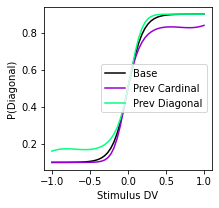

In [5]:
threshold = -0.0 # Threshold for detecting the stimulus
slope = 10  # Slope of the psychometric function
lapse_low = 0.1  # Lapse rate for low stimulus intensity
lapse_high = 0.1  # Lapse rate for high stimulus intensity

# Generate stimulus intensities
stimulus_intensities = np.linspace(-1, 1, 50)

# Define the psychometric function with lapses
def psychometric_function(x, threshold, slope, lapse_low, lapse_high, prev_sens, wbias):
    w = sinusoidal_function(x, -1, 1, 0.25, prev_sens ) * wbias
    prob = lapse_low + (1 - lapse_low - lapse_high) * (1 / (1 + np.exp(-(slope + w )* (x - threshold))))
    return prob


#def decimetric_function(x, threshold, slope, lapse_low, lapse_high, slp_coef, slp_phase):
#    slp_weight = sinusoidal_function(x, -1, 1, 0.25, slp_phase) # min val and max value, frequency and phase
#    slope = slope + (slp_coef * slp_weight)
#    prob = lapse_low + (1 - lapse_low - lapse_high) * (1 / (1 + np.exp(-slope * (x - threshold))))
#    deci = np.random.uniform(0, 1, size=len(prob))  < prob  # Use vectorized comparison #np.random.uniform(0, 1, size=len(prob))
#    return deci.astype(int)  # Convert boolean values to integers (0 or 1)



# Visualize the probabilities of discriminating C vs D
prob_detect_b = psychometric_function(stimulus_intensities, threshold, slope, lapse_low, lapse_high,np.deg2rad(180),0)

prob_detect = psychometric_function(stimulus_intensities, threshold, slope, lapse_low, lapse_high,np.deg2rad(180),0.75*10)
prob_detectb = psychometric_function(stimulus_intensities, threshold, slope, lapse_low, lapse_high,np.deg2rad(0),0.75*10)

plt.figure(figsize=(3,3))

# Plot the psychometric curve
plt.plot(stimulus_intensities, prob_detect_b,'black', label='Base')
plt.plot(stimulus_intensities, prob_detect,'darkviolet', label='Prev Cardinal')
plt.plot(stimulus_intensities, prob_detectb,'springgreen', label='Prev Diagonal')
plt.xlabel('Stimulus DV')
plt.ylabel('P(Diagonal)')
plt.legend()
plt.show()

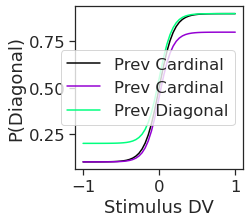

In [190]:
# Define the psychometric function with lapses
def psychometric_function(x, threshold, slope, lapse_low, lapse_high):
    prob = lapse_low + (1 - lapse_low - lapse_high) * (1 / (1 + np.exp(-(slope + 10)* (x - threshold))))
    return prob

threshold = -0.0 # Threshold for detecting the stimulus
slope = 0.5  # Slope of the psychometric function
lapse_low = 0.1  # Lapse rate for low stimulus intensity
lapse_high = 0.1  # Lapse rate for high stimulus intensity


# Visualize the probabilities of discriminating C vs D
prob_detect = psychometric_function(stimulus_intensities, threshold, slope, lapse_low, lapse_high)
prob_detect_C = psychometric_function(stimulus_intensities, threshold, slope + 1, lapse_low, lapse_high + 0.1)
prob_detect_D = psychometric_function(stimulus_intensities, threshold, slope + 1, lapse_low + 0.1, lapse_high)

plt.figure(figsize=(3,3))

# Plot the psychometric curve
plt.plot(stimulus_intensities, prob_detect, 'black', label='Prev Cardinal')
plt.plot(stimulus_intensities, prob_detect_C,'darkviolet', label='Prev Cardinal')
plt.plot(stimulus_intensities, prob_detect_D,'springgreen', label='Prev Diagonal')
plt.xlabel('Stimulus DV')
plt.ylabel('P(Diagonal)')
plt.legend()
plt.show()

In [369]:
np.random.normal(0, 4, 1)

array([2.49596868])

In [370]:
def rescale_matrix(matrix):
    """
    Rescales the matrix using z-scoring (standardization).
    Subtracts the mean and divides by the standard deviation, calculated globally.
    """
    mean_val = np.mean(matrix)
    std_val = np.std(matrix)

    # Avoid division by zero if the matrix has zero variance (e.g., all identical values)
    if std_val == 0:
        # Handle this case: perhaps return the matrix centered at 0, or just the original
        # Returning a zero matrix might be safest if std is 0
        scaled_matrix = matrix - mean_val
    else:
        scaled_matrix = (matrix - mean_val) / std_val

    return scaled_matrix



def create_exp():
    ntrials = 5000
    tseries = 500 # stim time 
    tseries_nostim = 200 # stim time
    stim_strengh = 0.4
    stim_var = 3
    nreps = 2

    # random data with a bias (stimulus)
    stim_data = np.random.normal(stim_strengh, stim_var, (ntrials, tseries))
    # randomizingg sign of the data for different trials options (+1 or -1 stimuli)
    stim_vector = np.random.choice([-1, 1], size=stim_data.shape[0])
    stim_data *= stim_vector[:, np.newaxis] # applying to the vectors

    stim_data = np.repeat(stim_data, nreps, axis = 0) # duplicating trials per number of repetitions
    mean_stim = np.mean(stim_data, axis = 1) # mean of energy of the stimulus in stimulus time

    # generating unbiased data (no stimulus)
    nostim_data = np.random.normal(0, stim_var, (ntrials*nreps, tseries_nostim))

    # combine data with stim and without stim
    sim_data = np.concatenate((stim_data,nostim_data), axis = 1)
    sim_data = rescale_matrix(sim_data) # rescale data between -1 and 1

    stim_vector = np.repeat(stim_vector, nreps, axis = 0)
    trial_rep = np.tile(np.array([0,1]), ntrials) # trial rep index

    # Concatenate the arrays along axis 1
    result = np.concatenate([stim_vector.reshape(-1, 1), trial_rep.reshape(-1, 1), mean_stim.reshape(-1, 1)], axis=1)
    sim_df = pd.DataFrame(result, columns=['stim', 'nrep','DV'])
    sim_df['pre_deci'] = np.random.choice([-1, 1], size=sim_df.shape[0]) # initialize random preresp 
    sim_df['deci'] = 0 
    sim_df['RT'] = 0
    return sim_df, sim_data


def psychometric_function_with_lapses(x, threshold, slope, lapse_low, lapse_high):
    return lapse_low + (1 - lapse_low - lapse_high) * (1 / (1 + np.exp(-slope  * (x - threshold))))

def decimetric_function(x, threshold, slope, lapse_low, lapse_high, slp_coef, slp_phase):
    probs = lapse_low + (1 - lapse_low - lapse_high) * (1 / (1 + np.exp(-slope * (x - threshold))))
    #deci = np.random.uniform(0, 1, size=len(prob))  < prob  # Use vectorized comparison #np.random.uniform(0, 1, size=len(prob))
    return probs  # Convert boolean values to integers (0 or 1)

# this function is to compare two matrices and set to zero the values that are different     
def compare_and_set_to_zero(m1, m2):
    result = np.copy(m1)
    for i in range(m1.shape[0]):
        for j in range(m1.shape[1]):
            if np.sign(m1[i][j]) != np.sign(m2[i][j]):
                result[i][j] = 0
    return result


# This function makes the whole simulation using the different funtions and returns a dataframe with the results

def sim_ddm(sim_data, sim_df, obs_knel, bias_par, ddm_par, stim_par):
    starting_bias = ddm_par['p_z']
    
    for inrep in [0,1]: # iterate over number of repetitions
        
        idx_nrep = sim_df[sim_df['nrep'] == inrep].index
        stims_samp = sim_data[idx_nrep, :]
        stims_samp = stims_samp.T   
        ddm_par['p_z'] = 0
        #prev_deci = df_sample['deci'].values

        # all this below should be a function
        # Initializing parameters matrixes
        thresholds = np.ones(stims_samp.shape) * obs_knel['threshold_val'] + np.random.normal(0, 0.1, 1) # adding some random variability to each simulated subject
        slopes = np.ones(stims_samp.shape) * obs_knel['slope_val'] + np.random.normal(0, 3, 1) # adding some random variability to each simulated subject
        lapses_low = np.ones(stims_samp.shape) * obs_knel['lapse_high_val']     # + lapse_bias * prev_deci
        lapses_high = np.ones(stims_samp.shape) * obs_knel['lapse_low_val']    # + lapse_bias * prev_deci

        prev_choice = np.random.choice([0, 1], size=stims_samp.shape[1])  #np.zeros(stims_samp.shape[1]) # for the first rep, just fill with zeros or ones
        slopephasesMat = np.zeros(stims_samp.shape[1]) # for the first rep, just fill with zeros
        slp_coef = 0

        # in first rep, initialize slope coef in 0

        if inrep > 0: # only previous history can affect after nrep = 0
           
            prev_choice =  np.sign(choice) #() #np.roll(choice,1)
            ddm_par['p_z'] = starting_bias
            
            #print(prev_choice)

            # changing lapses depending on previous choice
            # for cardinal
            prev_choice_diag = prev_choice.copy()
            prev_choice_diag[prev_choice_diag == -1] = 0
            prev_choice_diag = np.tile(prev_choice_diag, (stims_samp.shape[0], 1))
            # for diagonals
            prev_choice_card = prev_choice.copy()
            prev_choice_card[prev_choice_card == 1] = 0
            prev_choice_card = np.abs(prev_choice_card)
            prev_choice_card = np.tile(prev_choice_card, (stims_samp.shape[0], 1))

            # changing lapses depending on previous choice
            lapses_low = lapses_low + (bias_par['lapse_bias'] * prev_choice_diag) # change low lapse if previous choice was diagonal
            lapses_high = lapses_high + (bias_par['lapse_bias'] * prev_choice_card) # change high lapse if previous choice was cardinal

            # changing threshold depending on previous choice
            thresholds = thresholds + bias_par['threshold_bias'] * (prev_choice * -1)
            
            slopes = slopes + bias_par['slope_change'] # we increase the slope 
            
           
            # slopes = slopes + bias_par['slope_val_bias'] * prev_choice
            # changing slope (phase of sinusoidal) depending on previous choice
            slopephasesMat = prev_choice.copy()
            slopephasesMat[slopephasesMat == 1] = np.deg2rad(0)
            slopephasesMat[slopephasesMat == -1] = np.deg2rad(180)
            slp_coef = bias_par['slope_val_bias']
            
        # Calculate the probabilities for each element in the matrices
        #probs = psychometric_function_with_lapses(stims_samp, thresholds, slopes, lapses_low, lapses_high)
        probs = decimetric_function(stims_samp, thresholds, slopes, lapses_low, lapses_high, slp_coef, slopephasesMat)
        E = DDM_fun(probs,ddm_par,stim_par,  prev_choice, stims_samp) 
        choice, rts = bound_fun(E, ddm_par['bound'])
        # plot traces
        plt.plot(E[:,0:100], lw = 0.25)

        # concatenating everything in the dataframe
        sim_df.iloc[idx_nrep, sim_df.columns.get_loc('deci')] = np.sign(choice)
        sim_df.loc[sim_df['deci'] == -1, 'deci'] = 0
        sim_df.iloc[idx_nrep, sim_df.columns.get_loc('RT')] = rts
        sim_df.iloc[idx_nrep, sim_df.columns.get_loc('pre_deci')] = prev_choice
        sim_df.loc[sim_df['pre_deci'] == -1, 'pre_deci'] = 0
        # adding random pre_deci for nrep = 0
        sim_df.loc[sim_df['nrep'] == 0, 'pre_deci'] = np.random.choice([0, 1], size=sim_df[sim_df['nrep'] == 0].shape[0])

    return sim_df, E


# This function takes the observer psychometric kernel output and start a Diffusion process..
def DDM_fun(probs, ddm_par, stim_par, prev_choice, stims_samp):
    # random uniform probabilities
    sim_probs = np.random.uniform(low=0.0, high=1.0, size=probs.shape) 
    # transforming probabilities into evidence 
    stims_e = (probs > sim_probs).astype(int)
    stims_e = stims_e - 0.5
    multipl = stims_samp.copy()
    # select time points where the stimulus is presented
    multipl[multipl != 0] = 1
    # multiply x 0 when there is not stimulus presented
    stims_e = stims_e * multipl

    # instantaneous evidence
    ntrials = stims_e.shape[1]
    
    Ve = np.concatenate((np.zeros((ddm_par['p_t'],   ntrials)), stims_e)) 
    # adding drift criterion
    prev_choice_mat = np.repeat(np.expand_dims(np.sign(prev_choice), 1).T, Ve.shape[0], axis=0) # calculating drift criterion 
     ##Ve = compare_and_set_to_zero(Ve,  prev_choice_mat) # do not sample evidence incongruent with previous choice

    dc = ddm_par['p_c'] * prev_choice_mat
    Ve = Ve + dc # summing drift criterion if ddm_par['p_c'] != 0
    #Starting Diffusion Process (See that Ve is determined by the observer's psychometric function)
    prior =np.sign(prev_choice)*ddm_par['p_z']

    N = Ve.shape[0]
    #zero_or_noise_evidence = np.random.randn(N, num_tr)
    noise = np.random.normal(stim_par['mu'], stim_par['sigma'],Ve.shape)
    # add noise
    dW = noise + Ve #zero_or_noise_evidence*p_e_noise+Ve
    dW[0, :] = prior
    E = np.cumsum(dW, axis=0)
    return E
    




# This function takes the evidence and returns the choice and RT
def bound_fun(E, bound):
    rts = np.array([])
    choice = np.array([])
    for e_a_ind in E.T:
        try:
            idx = np.where(np.abs(e_a_ind) >= bound)[0][0]
            rts = np.append(rts, idx)
            choice = np.append(choice, e_a_ind[idx])
        except:
            rts = np.append(rts, np.nan)
            choice = np.append(choice, e_a_ind[-1]) # append the last one# np.nan
    return choice, rts





# run simulations and get paramaters / save RTs for each iteration
def simulate_it(nits,bias_par,ddm_par,stim_par, exp_bias, obs_knel):
    all_reslist = []
    all_datlist = []
    
    for its in range(nits):   
        sim_df, sim_data =  create_exp() # regenerate the simulated experiment in each iteration
        outsim_df, E = sim_ddm(sim_data, sim_df, obs_knel, bias_par, ddm_par, stim_par)
        
        outsim_df['ntrial'] = np.arange(1, sim_data.shape[0] + 1)
        outsim_df['nit'] = its
        outsim_df['exp_bias'] = exp_bias
        sim_data_df = pd.DataFrame(sim_data) 
        #['ntrial'] = np.arange(1, sim_data.shape[0] + 1)
        outsim_df = pd.concat([outsim_df, sim_data_df],axis = 1)
        
        # save iterations
        if its == 0:
            all_outsim_df = outsim_df.iloc[:,0:9]
        else:
            all_outsim_df = pd.concat([all_outsim_df,outsim_df.iloc[:,0:9]])  
            
        
        # model the two deci together in nrep 1
        reg = smf.glm(formula = 'deci~DV', data = outsim_df[(outsim_df.nrep==0)], family=sm.families.Binomial()).fit()
        params = reg.params
        t_idx = [its, 0, exp_bias]
        tparams = params.to_list()
        dat = np.array(t_idx + tparams)
        all_reslist.append(dat)
        
        # model the two deci together in nrep 1
        reg = smf.glm(formula = 'deci~DV', data = outsim_df[(outsim_df.nrep==1)], family=sm.families.Binomial()).fit()
        params = reg.params
        t_idx = [its, 1,  exp_bias]
        tparams = params.to_list()
        dat = np.array(t_idx + tparams)
        all_reslist.append(dat)
            
        
        # appending params nrep 0 
        reg = smf.glm(formula = 'deci~DV', data = outsim_df[(outsim_df.nrep==0) & (outsim_df.pre_deci==0)], family=sm.families.Binomial()).fit()
        params = reg.params
        t_idx = [its, 0, 0, exp_bias]
        tparams = params.to_list()
        dat = np.array(t_idx + tparams)
        all_datlist.append(dat)

        
        # appending params nrep 0 
        reg = smf.glm(formula = 'deci~DV', data = outsim_df[(outsim_df.nrep==0) & (outsim_df.pre_deci==1)], family=sm.families.Binomial()).fit()
        params = reg.params
        t_idx = [its, 0, 1, exp_bias]
        tparams = params.to_list()
        dat = np.array(t_idx + tparams)
        all_datlist.append(dat)

        # appending params nrep 1, predeci 0
        reg = smf.glm(formula = 'deci~DV', data = outsim_df[(outsim_df.nrep==1) & (outsim_df.pre_deci==0)], family=sm.families.Binomial()).fit()
        params = reg.params
        t_idx = [its, 1, 0, exp_bias]
        tparams = params.to_list()
        dat = np.array(t_idx + tparams)
        all_datlist.append(dat)
        # appending params nrep 1, , predeci 1
        reg = smf.glm(formula = 'deci~DV', data = outsim_df[(outsim_df.nrep==1) & (outsim_df.pre_deci==1)], family=sm.families.Binomial()).fit()
        params = reg.params
        t_idx = [its, 1, 1, exp_bias]
        tparams = params.to_list()
        dat = np.array(t_idx + tparams)
        all_datlist.append(dat)

    simrep_params = pd.DataFrame(all_reslist,  columns = ['niter', 'nrep', 'model', 'intercept', 'DV'])
    simdeci_params = pd.DataFrame(all_datlist,  columns = ['niter', 'nrep', 'pre_deci', 'model', 'intercept', 'DV'])

    column_types2 = {
        'niter': int,
        'nrep': int,
        'pre_deci': int,
        'model': str,
        'intercept': float,
        'DV': float
    }
    
    column_types = {
        'niter': int,
        'nrep': int,
        'model': str,
        'intercept': float,
        'DV': float
    }

    # Convert column types 
    simrep_params = simrep_params.astype(column_types)
    simdeci_params = simdeci_params.astype(column_types2)
    #plt.plot(E[:,0:100], lw = 0.25)
    
    return simrep_params, simdeci_params, all_outsim_df


def compute_condbias(x):
    rt_series = x['RT']

    # Remove or replace zero/negative RTs
    #rt_series = rt_series.clip(lower=1e-5)

    #log_rt = np.log(rt_series)
    #max_log_rt = log_rt.max()
    #transformed_rt = max_log_rt - log_rt

    transformed_rt = rt_series.copy()
    # Handle case where std is zero
    if transformed_rt.std() == 0:
        zRT = pd.Series(0, index=x.index)
    else:
        zRT = (transformed_rt - transformed_rt.mean()) / transformed_rt.std()

    x = x.copy()  # Avoid SettingWithCopyWarning
    x['zRT'] = zRT

    # Bin using qcut with error handling for duplicate edges
    try:
        x['qs'] = pd.qcut(x['zRT'], q=[0, 0.15, 0.3, 0.5, 0.7, 0.9, 1], labels=False, duplicates='drop')
    except ValueError:
        x['qs'] = np.nan  # or set a default value / bin

    return x

# Apply to groups


 prev_choice_mat = np.repeat(np.expand_dims(np.sign(prev_choice), 1).T, Ve.shape[0], axis=0) 
 out = compare_and_set_to_zero(Ve,  prev_choice_mat)

__Defining observer characteristics__

In [371]:
# Observer decision kernel parameters
obs_knel = {}
obs_knel['threshold_val'] = -0.025 # bias in the decision kernel
obs_knel['slope_val'] = 10 # how fast the evidence accumulates
obs_knel['lapse_low_val'] = 0.1
obs_knel['lapse_high_val'] = 0.1


## Selective bias model (lapse model)

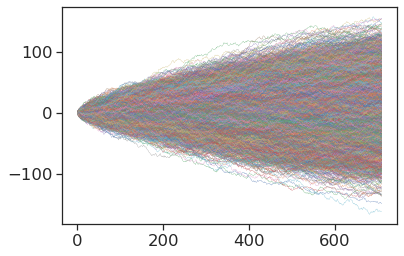

In [372]:
# Bias parameters_coefs
bias_par = {}
bias_par['threshold_bias'] = 0.0
bias_par['slope_val_bias'] = 0
bias_par['lapse_bias'] = 0.1
bias_par['slope_change'] = 0 # how slope changes from P1 to P2

# DDM parameters (DV is given by participants psychometric function and the stimulus)
ddm_par = {}
ddm_par['p_t'] = 10 # non-decision time
ddm_par['p_z'] = 0 # prior weight?
ddm_par['p_c'] = 0.0
ddm_par['bound'] = 30 # boundary separation

# stimuli noise parameters
stim_par = {}
stim_par['mu'] = 0
stim_par['sigma'] = 1
    
nits = 25 # number of iterations montecarlo
exp_bias = 'lapse_bias'

# if perfect separation error, re-run this code again
params_lapse_bias, params_deci_lapse_bias, simdata_lapse_bias = simulate_it(nits,bias_par,ddm_par,stim_par, exp_bias, obs_knel)



__Simulate one experiment traces for plotting__

sim_df, sim_data =  create_exp() # regenerate the simulated experiment in each iteration
outsim_df, E = sim_ddm(sim_data, sim_df, obs_knel, bias_par, ddm_par, stim_par)
plt.plot(E[:,0:20], lw = 0.25)

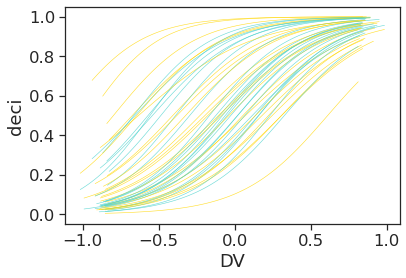

In [398]:

for i in np.arange(0,24):
    dat2=simdata_lapse_bias[(simdata_lapse_bias.nit == i)]
    for cell in [0,1]:
        sns.regplot(x="DV", y="deci",  data=dat2.loc[dat2.nrep == cell,:],
           logistic=True, y_jitter=0, scatter_kws={'alpha':0}, ci=True, n_boot=1,  label=cell,  truncate=True, 
                         line_kws ={'alpha':0.8, 'lw':0.6}, color = colpal2[cell]); #mean all subject


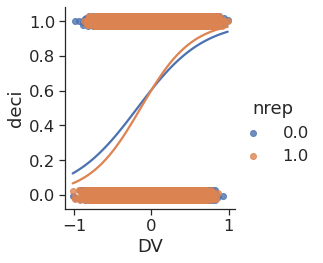

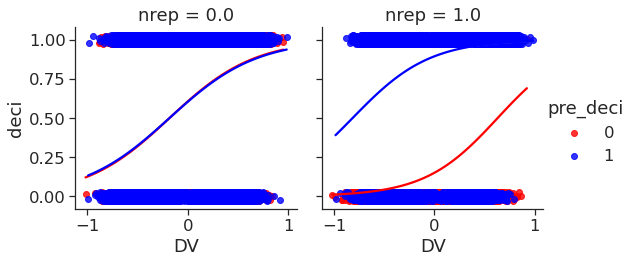

In [374]:
sns.lmplot(
    data=simdata_lapse_bias, x="DV", y="deci",
    hue="nrep", height=4, logistic=True, y_jitter=.03, n_boot=2
)


sns.lmplot(
    data=simdata_lapse_bias, x="DV", y="deci",
    hue="pre_deci", col = 'nrep' , height=4, logistic=True, y_jitter=.03, n_boot=2, 
    hue_order = [0,1],palette=['red','blue']
)

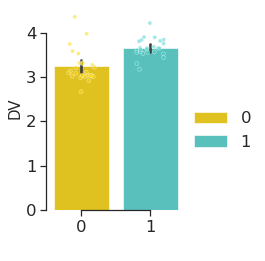

In [375]:
dx = 'nrep'; dy = 'DV'; hue = 'nrep';  row = None; col = None
colpal2 = ['gold','mediumturquoise','darkblue']
sizeplot = {}; sizeplot['height'] = 4; sizeplot['aspect'] = 0.8
axislabels = {}; axislabels['xlabel'] = ' '; axislabels['ylabel']= dy
yaxis = None # yaxis = {}; yaxis['ylim']=[-2,4], yaxis['yticks']=[-2, 0, 2, 4]
pal = colpal2

barsplot(params_lapse_bias, dx, dy, hue, col, row, pal, sizeplot, yaxis, axislabels, sizepoint = 4, dodge = False)


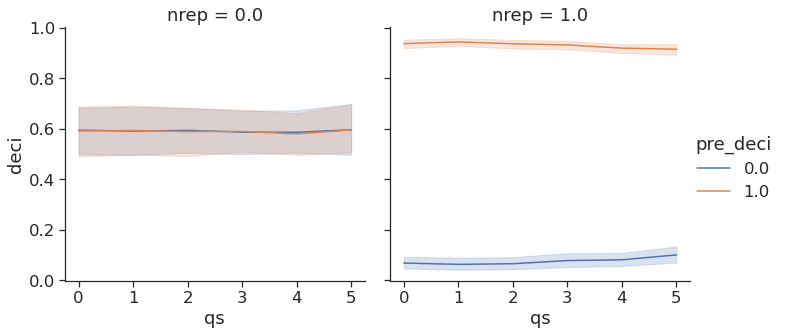

In [376]:
#dat = simdata_lapse_bias.copy()
dat = simdata_lapse_bias.copy()
dat = dat.groupby(['nit', 'nrep','pre_deci'], group_keys=False).apply(compute_condbias).reset_index(drop=True)
outmean = dat.groupby(['nit','nrep','pre_deci','qs'],as_index=False)['deci'].mean()

sns.relplot(
   data=outmean, x="qs", y="deci", hue="pre_deci",
    kind="line", col = 'nrep'
)

In [51]:
 params_deci_lapse_bias

,niter,nrep,pre_deci,model,intercept,DV
0,0,0,0,lapse_bias,0.368563,3.275941
1,0,0,1,lapse_bias,0.304793,3.094255
2,0,1,0,lapse_bias,-1.807343,2.921397
3,0,1,1,lapse_bias,2.381528,3.397355
4,1,0,0,lapse_bias,0.271791,3.158301
5,1,0,1,lapse_bias,0.252670,3.046342
6,1,1,0,lapse_bias,-1.776150,3.064988
7,1,1,1,lapse_bias,2.436711,3.255955


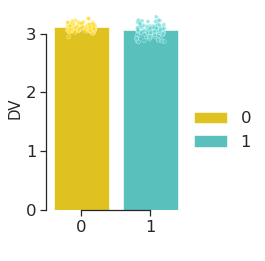

In [13]:
params_avgdeci_lapse_bias = params_deci_lapse_bias.groupby(['niter', 'nrep', 'model'],as_index=False)[['intercept','DV']].mean()

dx = 'nrep'; dy = 'DV'; hue = 'nrep';  row = None; col = None
colpal2 = ['gold','mediumturquoise','darkblue']
sizeplot = {}; sizeplot['height'] = 4; sizeplot['aspect'] = 0.8
axislabels = {}; axislabels['xlabel'] = ' '; axislabels['ylabel']= dy
yaxis = None # yaxis = {}; yaxis['ylim']=[-2,4], yaxis['yticks']=[-2, 0, 2, 4]
pal = colpal2

barsplot(params_avgdeci_lapse_bias, dx, dy, hue, col, row, pal, sizeplot, yaxis, axislabels, sizepoint = 4, dodge = False)


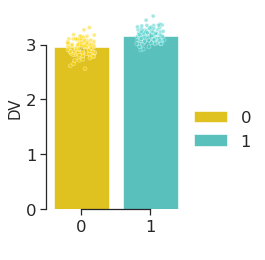

In [14]:


dx = 'pre_deci'; dy = 'DV'; hue = 'pre_deci';  row = None; col = None
colpal2 = ['gold','mediumturquoise','darkblue']
sizeplot = {}; sizeplot['height'] = 4; sizeplot['aspect'] = 0.8
axislabels = {}; axislabels['xlabel'] = ' '; axislabels['ylabel']= dy
yaxis = None # yaxis = {}; yaxis['ylim']=[-2,4], yaxis['yticks']=[-2, 0, 2, 4]
pal = colpal2

barsplot(params_deci_lapse_bias[params_deci_lapse_bias.nrep == 1], dx, dy, hue, col, row, pal, sizeplot, yaxis, axislabels, sizepoint = 4, dodge = False)


## Selective bias model (slope model)

this model assumes that sensitivity changes dynamically with the distance of the sample to the previous choice. This model is esentially the same as the lapse model although a bit more complex

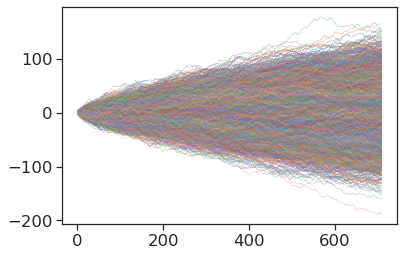

In [378]:
# Bias parameters_coefs
bias_par = {}
bias_par['threshold_bias'] = 0.0
bias_par['slope_val_bias'] = 0
bias_par['lapse_bias'] = 0.1
bias_par['slope_change'] = 1 # how slope changes from P1 to P2 [if you increase a lot of the slope, the model will not show the reduction in slope

# DDM parameters (DV is given by participants psychometric function and the stimulus)
ddm_par = {}
ddm_par['p_t'] = 10 # non-decision time
ddm_par['p_z'] = 0 # prior weight?
ddm_par['p_c'] = 0.0
ddm_par['bound'] = 30 # boundary separation

# stimuli noise parameters
stim_par = {}
stim_par['mu'] = 0
stim_par['sigma'] = 1
    
nits = 25 # number of iterations montecarlo
exp_bias = 'sensitivity_bias'

params_sensi_bias, params_deci_sensi_bias, simdata_sensi_bias = simulate_it(nits,bias_par,ddm_par,stim_par, exp_bias, obs_knel)


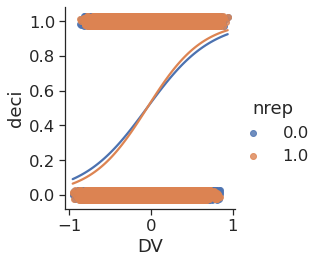

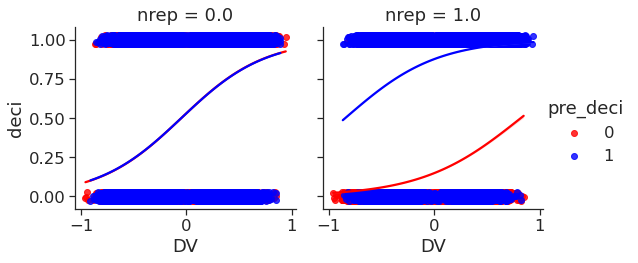

In [379]:
sns.lmplot(
    data=simdata_sensi_bias, x="DV", y="deci",
    hue="nrep", height=4, logistic=True, y_jitter=.03, n_boot=2
)



sns.lmplot(
    data=simdata_sensi_bias, x="DV", y="deci",
    hue="pre_deci", col = 'nrep' , height=4, logistic=True, y_jitter=.03, n_boot=2, 
    hue_order = [0,1],palette=['red','blue']
)

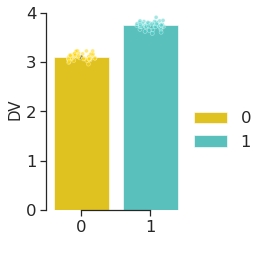

In [80]:
dx = 'nrep'; dy = 'DV'; hue = 'nrep';  row = None; col = None
colpal2 = ['gold','mediumturquoise','darkblue']
sizeplot = {}; sizeplot['height'] = 4; sizeplot['aspect'] = 0.8
axislabels = {}; axislabels['xlabel'] = ' '; axislabels['ylabel']= dy
yaxis = None # yaxis = {}; yaxis['ylim']=[-2,4], yaxis['yticks']=[-2, 0, 2, 4]
pal = colpal2

barsplot(params_sensi_bias, dx, dy, hue, col, row, pal, sizeplot, yaxis, axislabels, sizepoint = 4, dodge = False)


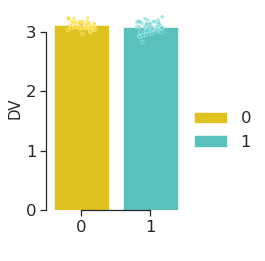

In [81]:
params_avgdeci_sensi_bias = params_deci_sensi_bias.groupby(['niter', 'nrep', 'model'],as_index=False)[['intercept','DV']].mean()

dx = 'nrep'; dy = 'DV'; hue = 'nrep';  row = None; col = None
colpal2 = ['gold','mediumturquoise','darkblue']
sizeplot = {}; sizeplot['height'] = 4; sizeplot['aspect'] = 0.8
axislabels = {}; axislabels['xlabel'] = ' '; axislabels['ylabel']= dy
yaxis = None # yaxis = {}; yaxis['ylim']=[-2,4], yaxis['yticks']=[-2, 0, 2, 4]
pal = colpal2

barsplot(params_avgdeci_sensi_bias, dx, dy, hue, col, row, pal, sizeplot, yaxis, axislabels, sizepoint = 4, dodge = False)


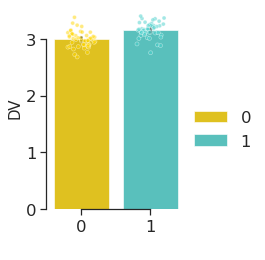

In [82]:


dx = 'pre_deci'; dy = 'DV'; hue = 'pre_deci';  row = None; col = None
colpal2 = ['gold','mediumturquoise','darkblue']
sizeplot = {}; sizeplot['height'] = 4; sizeplot['aspect'] = 0.8
axislabels = {}; axislabels['xlabel'] = ' '; axislabels['ylabel']= dy
yaxis = None # yaxis = {}; yaxis['ylim']=[-2,4], yaxis['yticks']=[-2, 0, 2, 4]
pal = colpal2

barsplot(params_deci_sensi_bias[params_deci_sensi_bias.nrep == 1], dx, dy, hue, col, row, pal, sizeplot, yaxis, axislabels, sizepoint = 4, dodge = False)


## Non selective bias model (threshold model)

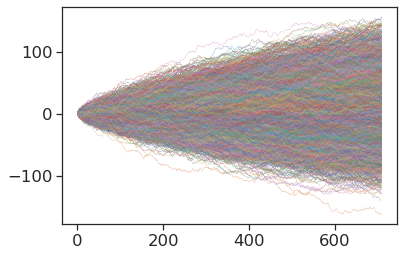

In [381]:

# Bias parameters_coefs
bias_par = {}
bias_par['threshold_bias'] = 0.15
bias_par['slope_val_bias'] = 0
bias_par['lapse_bias'] = 0.0
bias_par['slope_change'] = 0 # how slope changes from P1 to P2


# DDM parameters (DV is given by participants psychometric function and the stimulus)
ddm_par = {}
ddm_par['p_t'] = 10 # non-decision time
ddm_par['p_z'] = 0 # prior weight?
ddm_par['p_c'] = 0.0
ddm_par['bound'] = 30 # boundary separation

# stimuli noise parameters
stim_par = {}
stim_par['mu'] = 0
stim_par['sigma'] = 1
    
nits = 25 # number of iterations montecarlo
exp_bias = 'threshold_bias'


params_threshold_bias, params_deci_threshold_bias, simdata_threshold_bias = simulate_it(nits,bias_par,ddm_par,stim_par, exp_bias, obs_knel)


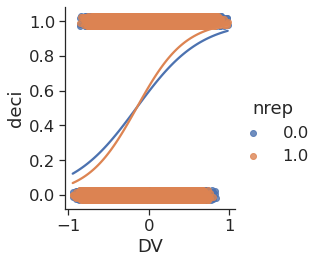

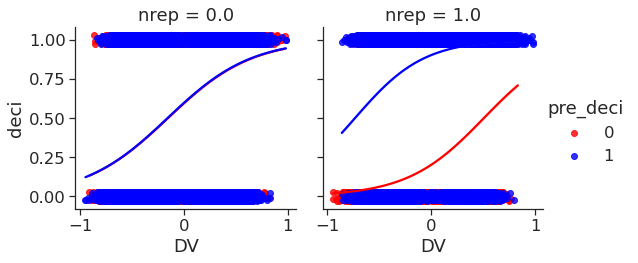

In [382]:
sns.lmplot(
    data=simdata_threshold_bias, x="DV", y="deci",
    hue="nrep", height=4, logistic=True, y_jitter=.03, n_boot=10
)



sns.lmplot(
    data=simdata_threshold_bias, x="DV", y="deci",
    hue="pre_deci", col = 'nrep' , height=4, logistic=True, y_jitter=.03, n_boot=10, 
    hue_order = [0,1],palette=['red','blue']
)

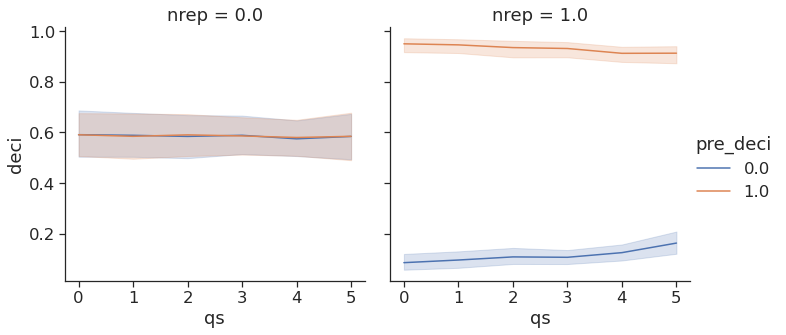

In [384]:
#dat = simdata_lapse_bias.copy()
dat = simdata_threshold_bias.copy()
dat = dat.groupby(['nit', 'nrep','pre_deci'], group_keys=False).apply(compute_condbias).reset_index(drop=True)
outmean = dat.groupby(['nit','nrep','pre_deci','qs'],as_index=False)['deci'].mean()

sns.relplot(
   data=outmean, x="qs", y="deci", hue="pre_deci",
    kind="line", col = 'nrep'
)

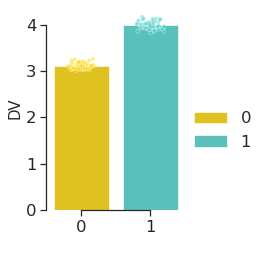

In [86]:
dx = 'nrep'; dy = 'DV'; hue = 'nrep';  row = None; col = None
colpal2 = ['gold','mediumturquoise','darkblue']
sizeplot = {}; sizeplot['height'] = 4; sizeplot['aspect'] = 0.8
axislabels = {}; axislabels['xlabel'] = ' '; axislabels['ylabel']= dy
yaxis = None # yaxis = {}; yaxis['ylim']=[-2,4], yaxis['yticks']=[-2, 0, 2, 4]
pal = colpal2

barsplot(params_threshold_bias, dx, dy, hue, col, row, pal, sizeplot, yaxis, axislabels, sizepoint = 4, dodge = False)


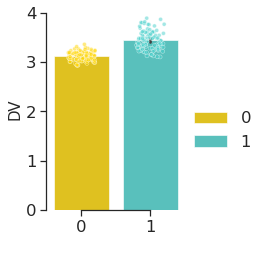

In [87]:
params_avgdeci_threshold_bias = params_deci_threshold_bias.groupby(['niter', 'nrep', 'model'],as_index=False)[['intercept','DV']].mean()

dx = 'nrep'; dy = 'DV'; hue = 'nrep';  row = None; col = None
colpal2 = ['gold','mediumturquoise','darkblue']
sizeplot = {}; sizeplot['height'] = 4; sizeplot['aspect'] = 0.8
axislabels = {}; axislabels['xlabel'] = ' '; axislabels['ylabel']= dy
yaxis = None # yaxis = {}; yaxis['ylim']=[-2,4], yaxis['yticks']=[-2, 0, 2, 4]
pal = colpal2

barsplot(params_deci_threshold_bias, dx, dy, hue, col, row, pal, sizeplot, yaxis, axislabels, sizepoint = 4, dodge = False)


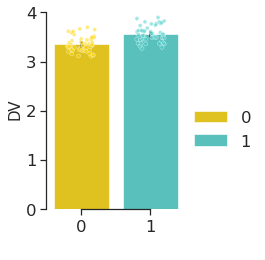

In [88]:
dx = 'pre_deci'; dy = 'DV'; hue = 'pre_deci';  row = None; col = None
colpal2 = ['gold','mediumturquoise','darkblue']
sizeplot = {}; sizeplot['height'] = 4; sizeplot['aspect'] = 0.8
axislabels = {}; axislabels['xlabel'] = ' '; axislabels['ylabel']= dy
yaxis = None # yaxis = {}; yaxis['ylim']=[-2,4], yaxis['yticks']=[-2, 0, 2, 4]
pal = colpal2

barsplot(params_deci_threshold_bias[params_deci_threshold_bias.nrep == 1], dx, dy, hue, col, row, pal, sizeplot, yaxis, axislabels, sizepoint = 4, dodge = False)


## Z model

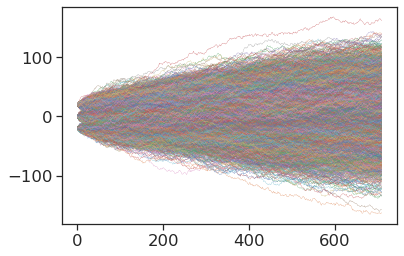

In [385]:
# Bias parameters_coefs
bias_par = {}
bias_par['threshold_bias'] = 0.0
bias_par['slope_val_bias'] = 0.0
bias_par['lapse_bias'] = 0.0
bias_par['slope_change'] = 0 # how slope changes from P1 to P2


# DDM parameters (DV is given by participants psychometric function and the stimulus)
ddm_par = {}
ddm_par['p_t'] = 10 # non-decision time
ddm_par['p_z'] = 20 # prior weight?
ddm_par['p_c'] = 0.0
ddm_par['bound'] = 30 # boundary separation

# stimuli noise parameters
stim_par = {}
stim_par['mu'] = 0
stim_par['sigma'] = 1
    
nits = 25 # number of iterations montecarlo

exp_bias = 'Z_bias'


params_Z_bias, params_deci_Z_bias, simdata_Z_bias = simulate_it(nits,bias_par,ddm_par,stim_par, exp_bias, obs_knel)
    

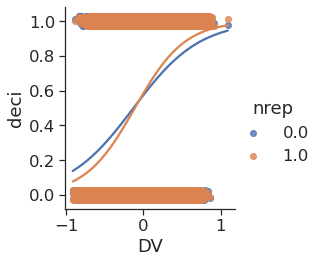

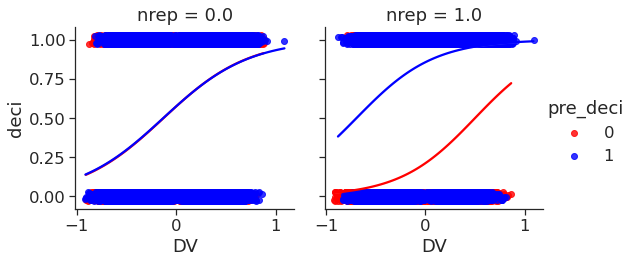

In [386]:
sns.lmplot(
    data=simdata_Z_bias, x="DV", y="deci",
    hue="nrep", height=4, logistic=True, y_jitter=.03, n_boot=10
)



sns.lmplot(
    data=simdata_Z_bias, x="DV", y="deci",
    hue="pre_deci", col = 'nrep' , height=4, logistic=True, y_jitter=.03, n_boot=10, 
    hue_order = [0,1],palette=['red','blue']
)

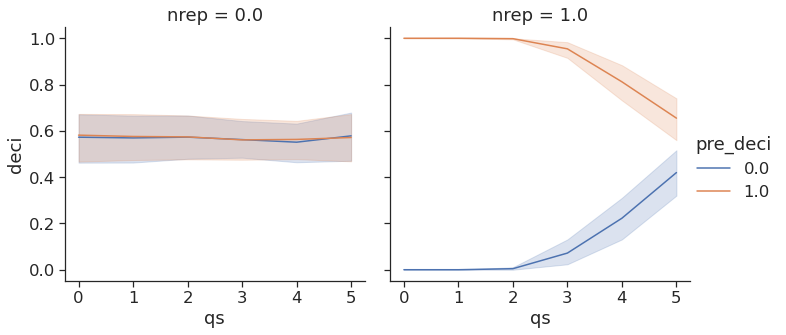

In [388]:
#dat = simdata_lapse_bias.copy()
dat = simdata_Z_bias.copy()
dat = dat.groupby(['nit', 'nrep','pre_deci'], group_keys=False).apply(compute_condbias).reset_index(drop=True)
outmean = dat.groupby(['nit','nrep','pre_deci','qs'],as_index=False)['deci'].mean()

sns.relplot(
   data=outmean, x="qs", y="deci", hue="pre_deci",
    kind="line", col = 'nrep'
)

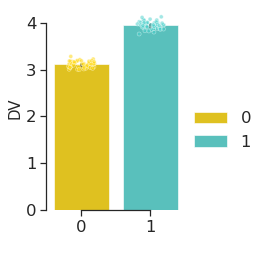

In [92]:
dx = 'nrep'; dy = 'DV'; hue = 'nrep';  row = None; col = None
colpal2 = ['gold','mediumturquoise','darkblue']
sizeplot = {}; sizeplot['height'] = 4; sizeplot['aspect'] = 0.8
axislabels = {}; axislabels['xlabel'] = ' '; axislabels['ylabel']= dy
yaxis = None # yaxis = {}; yaxis['ylim']=[-2,4], yaxis['yticks']=[-2, 0, 2, 4]
pal = colpal2

barsplot(params_Z_bias, dx, dy, hue, col, row, pal, sizeplot, yaxis, axislabels, sizepoint = 4, dodge = False)


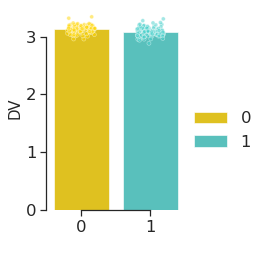

In [93]:

params_avgdeci_slope_bias = params_deci_slope_bias.groupby(['niter', 'nrep', 'model'],as_index=False)[['intercept','DV']].mean()

dx = 'nrep'; dy = 'DV'; hue = 'nrep';  row = None; col = None
colpal2 = ['gold','mediumturquoise','darkblue']
sizeplot = {}; sizeplot['height'] = 4; sizeplot['aspect'] = 0.8
axislabels = {}; axislabels['xlabel'] = ' '; axislabels['ylabel']= dy
yaxis = None # yaxis = {}; yaxis['ylim']=[-2,4], yaxis['yticks']=[-2, 0, 2, 4]
pal = colpal2

barsplot(params_avgdeci_slope_bias, dx, dy, hue, col, row, pal, sizeplot, yaxis, axislabels, sizepoint = 4, dodge = False)


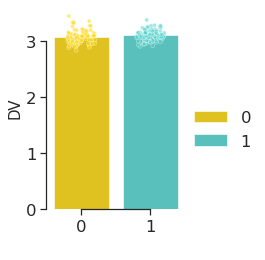

In [94]:
dx = 'pre_deci'; dy = 'DV'; hue = 'pre_deci';  row = None; col = None
colpal2 = ['gold','mediumturquoise','darkblue']
sizeplot = {}; sizeplot['height'] = 4; sizeplot['aspect'] = 0.8
axislabels = {}; axislabels['xlabel'] = ' '; axislabels['ylabel']= dy
yaxis = None # yaxis = {}; yaxis['ylim']=[-2,4], yaxis['yticks']=[-2, 0, 2, 4]
pal = colpal2

barsplot(params_deci_slope_bias[params_deci_slope_bias.nrep == 1], dx, dy, hue, col, row, pal, sizeplot, yaxis, axislabels, sizepoint = 4, dodge = False)


Concatenate all data and save to generate the figures

__Saving data__

In [172]:
params_deci_sensi_bias

,niter,nrep,pre_deci,model,intercept,DV
0,0,0,0,sensitivity_bias,0.034984,2.362751
1,0,0,1,sensitivity_bias,-0.027177,2.288328
2,0,1,0,sensitivity_bias,-2.003998,2.164067
3,0,1,1,sensitivity_bias,1.983941,2.454245
4,1,0,0,sensitivity_bias,0.469107,2.321200
...,...,...,...,...,...,...
395,98,1,1,sensitivity_bias,0.147588,2.144758
396,99,0,0,sensitivity_bias,0.436023,2.202251
397,99,0,1,sensitivity_bias,0.382377,2.354293
398,99,1,0,sensitivity_bias,-1.557053,2.400656


In [389]:
all_sims = pd.concat([params_deci_lapse_bias,params_deci_threshold_bias,params_deci_slope_bias,params_deci_Z_bias,params_deci_sensi_bias])
all_simdata = pd.concat([simdata_lapse_bias,simdata_threshold_bias,simdata_slope_bias,simdata_Z_bias,simdata_sensi_bias])

In [390]:
if platform.system() == 'Linux':
    sys_dir = os.path.join('/home/jovyan/work', 'OneDrive Biz')  # Linux   
    results_path = '/home/jovyan/work/OneDrive Biz/PROJECTS/Condcision/' # Linux Mundet


import pickle

# Specify the filename where you want to save the pickle file
pickle_file = results_path + 'Group_level_analyses/sim_data/all_sims.pickle'

# Open the file in binary write mode and dump the data variable into it
with open(pickle_file, 'wb') as f:
    pickle.dump(all_sims, f)


# Specify the filename where you want to save the pickle file
pickle_file = results_path + 'Group_level_analyses/sim_data/all_simdata.pickle'

# Open the file in binary write mode and dump the data variable into it
with open(pickle_file, 'wb') as f:
    pickle.dump(all_simdata, f)

__Loading the data__

In [232]:
import pickle
if platform.system() == 'Linux':
    sys_dir = os.path.join('/home/jovyan/work', 'OneDrive Biz')  # Linux   
    results_path = '/home/jovyan/work/OneDrive Biz/PROJECTS/Condcision/' # Linux Mundet


In [237]:
pickle_file = results_path + 'Group_level_analyses/sim_data/all_simdata.pickle'

with open(pickle_file, 'rb') as fp:
    all_simdata = pickle.load(fp)

,stim,nrep,DV,pre_deci,deci,RT,ntrial,nit,exp_bias
0,-1.0,0.0,-0.252647,0.0,0.0,591.0,1,0,lapse_bias
1,-1.0,1.0,-0.252647,0.0,1.0,242.0,2,0,lapse_bias
2,-1.0,0.0,-0.133679,0.0,0.0,308.0,3,0,lapse_bias
3,-1.0,1.0,-0.133679,0.0,0.0,160.0,4,0,lapse_bias
4,-1.0,0.0,-0.394269,0.0,1.0,NaN,5,0,lapse_bias
...,...,...,...,...,...,...,...,...,...
19995,-1.0,1.0,-0.444792,0.0,0.0,20.0,19996,49,Z_bias
19996,-1.0,0.0,-0.233447,1.0,0.0,449.0,19997,49,Z_bias
19997,-1.0,1.0,-0.233447,0.0,0.0,217.0,19998,49,Z_bias
19998,1.0,0.0,0.500052,0.0,0.0,454.0,19999,49,Z_bias


In [238]:
simdata_lapse_bias = all_simdata[all_simdata.exp_bias == 'lapse_bias']
simdata_threshold_bias = all_simdata[all_simdata.exp_bias == 'threshold_bias']
simdata_slope_bias = all_simdata[all_simdata.exp_bias == 'slope_bias']
simdata_Z_bias = all_simdata[all_simdata.exp_bias == 'Z_bias']


In [393]:

csv_file = results_path + 'Group_level_analyses/sim_data/all_simdata.csv'

all_simdata = pd.concat([simdata_lapse_bias, simdata_threshold_bias , simdata_slope_bias, simdata_Z_bias ])
all_simdata.to_csv(csv_file, index=False)

In [395]:
pickle_file = results_path + 'Group_level_analyses/sim_data/all_sims.pickle'
with open(pickle_file, 'rb') as fp:
    all_sims = pickle.load(fp)

In [396]:
params_deci_lapse_bias = all_sims[all_sims.model == 'lapse_bias']
params_deci_threshold_bias = all_sims[all_sims.model == 'threshold_bias']
params_deci_slope_bias = all_sims[all_sims.model == 'slope_bias']
params_deci_Z_bias = all_sims[all_sims.model == 'Z_bias']

In [397]:

csv_file = results_path + 'Group_level_analyses/sim_data/all_sims.csv'

all_sims = pd.concat([params_deci_lapse_bias, params_deci_threshold_bias , params_deci_slope_bias , params_deci_Z_bias  ])
all_sims.to_csv(csv_file, index=False)

__Modelling simulated data using HDDM__

## Drift diffusion analyses

 __HDDM cheat sheet__

 v     = drift rate
 a     = boundary separation
 t     = nondecision time
 z     = starting point
 dc    = drift driterion
 sv    = inter-trial variability in drift-rate
 st    = inter-trial variability in non-decision time
 sz    = inter-trial variability in starting-point


In [399]:
import hddm

# ============================================ #
# also compute BIC, AIC
# from https://groups.google.com/forum/#!searchin/hddm-users/bic%7Csort:date/hddm-users/Bo2vUcpR008/RLRpL0faptAJ
# ============================================ #
def aic(self):
    k = len(self.get_stochastics())
    logp = sum([x.logp for x in self.get_observeds()['node']])  
    return 2 * k - 2 * logp

def bic(self):
    k = len(self.get_stochastics())
    n = len(self.data)
    logp = sum([x.logp for x in self.get_observeds()['node']])
    return -2 * logp + k * np.log(n)

# model comparison function
def GLRT(mod1, mod2):
    
    chi_square = 2 * abs(mod1.logLike - mod2.logLike)
    delta_params = abs(len(mod1.coefs) - len(mod2.coefs)) 
    
    return {"chi_square" : chi_square, "df": delta_params, "p" : 1 - stats.chi2.cdf(chi_square, df=delta_params)}

In [400]:
n_samples = 1000

# lapse model

In [401]:
mydata = simdata_lapse_bias.copy()
mydata = mydata[mydata.RT > 0.0]
mydata.loc[mydata.stim == -1, 'stim'] = 0
mydata.rename(columns= {'deci' : 'response', 'RT' : 'rt', 'stim':'Stimuli','pre_deci':'response1','nit':'subj_idx'}, inplace=True)
mydata.rt = mydata.rt/100
mydata = mydata[mydata.subj_idx < 25]



In [402]:
simdata = 'lapse'

<AxesSubplot:title={'center':'RT distributions'}, xlabel='RT', ylabel='count'>

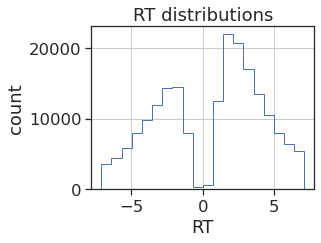

In [403]:
data = hddm.utils.flip_errors(mydata) 
#data = mydata.copy()
fig = plt.figure(figsize=[4,3])
ax = fig.add_subplot(111, xlabel='RT', ylabel='count', title='RT distributions')

data.rt.hist(bins=20, histtype='step', ax=ax)

nohist

In [404]:
model_name = simdata + '_sim_nohist'

In [405]:
hddm_m_path = os.path.join(results_path,'Group_level_analyses','hddm_models')
model_filename  = os.path.join(hddm_m_path, model_name)
print(model_filename)

/home/jovyan/work/OneDrive Biz/PROJECTS/Condcision/Group_level_analyses/hddm_models/lapse_sim_nohist


In [406]:
m_lapse_nohist = hddm.HDDMStimCoding(mydata, stim_col='Stimuli', split_param='v',
                        drift_criterion=False, bias=True, p_outlier=0.05,
                        include=('sv', 'sz'), group_only_nodes=['sv', 'sz'],
                        depends_on={ 'v':['nrep']}) 

m_lapse_nohist.sample(n_samples, burn=n_samples/2, thin=3, db='pickle', #n_samples
        dbname = model_filename + '.db')


 [-----------------100%-----------------] 1001 of 1000 complete in 14452.1 sec

In [407]:
m_lapse_nohist.save(model_filename+'_fm.db')

In [408]:
m_lapse_nohist.print_stats()

                       mean       std       2.5q        25q        50q        75q      97.5q    mc err
a                  9.102874  1.698309   6.120943   8.006773   9.015451  10.074353  12.893077  0.172656
a_std              9.212260  0.819664   7.727349   8.621471   9.116097   9.708519  11.130035  0.086458
a_subj.0          72.939880  0.607115  72.238021  72.482186  72.566940  73.448034  74.023069  0.062411
a_subj.1          14.710081  0.604299  13.769875  14.220581  14.565115  15.261186  15.695369  0.052335
a_subj.2          11.895019  0.559076  11.053657  11.453467  11.704153  12.515550  12.687065  0.046800
a_subj.3          66.858396  1.455205  64.831889  65.227961  66.798988  68.470494  68.781338  0.084671
a_subj.4          10.287780  0.437467   9.648191   9.846173  10.276332  10.669829  10.974094  0.029995
a_subj.5           8.784213  0.339506   8.314569   8.498146   8.663318   9.122971   9.389302  0.028733
a_subj.6          14.776141  0.666831  13.842893  14.173794  14.613282  1

dc

In [409]:
model_name = simdata + '_sim_dc'

In [410]:
hddm_m_path = os.path.join(results_path,'Group_level_analyses','hddm_models')
model_filename  = os.path.join(hddm_m_path, model_name)
print(model_filename)

/home/jovyan/work/OneDrive Biz/PROJECTS/Condcision/Group_level_analyses/hddm_models/lapse_sim_dc


In [411]:
m_lapse_stimcoding_dc_prevresp = hddm.HDDMStimCoding(mydata, stim_col='Stimuli', split_param='v',
                            drift_criterion=True, bias=True, p_outlier=0.05,
                            include=('sv', 'sz'), group_only_nodes=['sv', 'sz'],
                            depends_on={ 'dc':['nrep','response1'], 'v':['nrep']})
m_lapse_stimcoding_dc_prevresp.sample(n_samples, burn=n_samples/2, thin=3, db='pickle',
        dbname = model_filename + '.db')
                

 [-----------------100%-----------------] 1001 of 1000 complete in 15190.1 sec

In [412]:
m_lapse_stimcoding_dc_prevresp.save(model_filename+'_fm.db')

In [413]:
m_lapse_stimcoding_dc_prevresp.print_stats()

                               mean           std          2.5q           25q           50q           75q         97.5q        mc err
a                      3.763288e+00  7.275836e-01  2.562655e+00  3.318338e+00  3.683732e+00  4.291087e+00  5.337645e+00  7.465658e-02
a_std                  1.277074e+01  1.057603e+00  1.050783e+01  1.212170e+01  1.277469e+01  1.346743e+01  1.471262e+01  1.081841e-01
a_subj.0               2.837024e+01  8.210836e-01  2.698762e+01  2.766349e+01  2.835274e+01  2.907793e+01  2.979398e+01  5.522387e-02
a_subj.1               2.797533e+01  8.174182e-01  2.658984e+01  2.717530e+01  2.819917e+01  2.862641e+01  2.927859e+01  3.760223e-02
a_subj.2               2.516280e+01  7.919403e-01  2.379732e+01  2.441303e+01  2.540292e+01  2.582749e+01  2.634997e+01  3.751781e-02
a_subj.3               2.647561e+01  8.097088e-01  2.516447e+01  2.564609e+01  2.678736e+01  2.718928e+01  2.763538e+01  3.471049e-02
a_subj.4               2.377164e+01  7.104789e-01  2.267016e+0

_Z_

In [414]:
model_name = simdata + '_sim_Z'

In [415]:
hddm_m_path = os.path.join(results_path,'Group_level_analyses','hddm_models')
model_filename  = os.path.join(hddm_m_path, model_name)
print(model_filename)

/home/jovyan/work/OneDrive Biz/PROJECTS/Condcision/Group_level_analyses/hddm_models/lapse_sim_Z


In [416]:
m_lapse_stimcoding_z_prevresp = hddm.HDDMStimCoding(mydata, stim_col='Stimuli', split_param='v',
                            drift_criterion=False, bias=True, p_outlier=0.05,
                            include=('sv', 'sz'), group_only_nodes=['sv', 'sz'],
                            depends_on={ 'v':['nrep'], 'z':['nrep','response1']})
m_lapse_stimcoding_z_prevresp.sample(n_samples, burn=n_samples/2, thin=3, db='pickle',
        dbname = model_filename + '.db')
                

 [-----------------100%-----------------] 1001 of 1000 complete in 12510.2 sec

In [417]:
m_lapse_stimcoding_z_prevresp.save(model_filename+'_fm.db')

In [418]:
m_lapse_stimcoding_z_prevresp.print_stats()

                           mean        std       2.5q        25q        50q        75q      97.5q    mc err
a                     16.660005   5.748117   8.890791  11.982065  14.906442  20.573619  28.091588  0.517032
a_std                  9.402689   1.112743   7.462829   8.625254   9.272301  10.203195  11.735999  0.111878
a_subj.0              59.538956  14.000410  42.149583  44.693226  71.735963  72.935028  74.034607  1.136387
a_subj.1              30.421930   9.061537  15.408981  23.167075  31.452954  39.843190  42.226268  0.496982
a_subj.2              22.694016   6.762655  11.656224  16.877845  22.227756  29.712265  32.248412  0.383916
a_subj.3              31.873853   9.623019  16.255354  23.853109  30.401714  41.117194  45.565141  0.549339
a_subj.4              19.983344   6.054772  10.212192  14.870792  19.179282  26.353070  28.315352  0.351271
a_subj.5              16.391055   4.934713   8.707128  11.972448  15.978096  21.559345  23.357433  0.283080
a_subj.6              29.043

# Z model

In [419]:
simdata = 'Z'

In [420]:
mydata = simdata_Z_bias.copy()
mydata = mydata[mydata.RT > 0.0]
mydata.loc[mydata.stim == -1, 'stim'] = 0
mydata.rename(columns= {'deci' : 'response', 'RT' : 'rt', 'stim':'Stimuli','pre_deci':'response1','nit':'subj_idx'}, inplace=True)
mydata.rt = mydata.rt/100
mydata = mydata[mydata.subj_idx < 25]
mydata['subj_idx'] =  mydata['subj_idx'].astype('category')


<AxesSubplot:title={'center':'RT distributions'}, xlabel='RT', ylabel='count'>

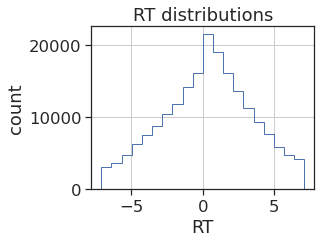

In [421]:
data = hddm.utils.flip_errors(mydata) 
#data = mydata.copy()
fig = plt.figure(figsize=[4,3])
ax = fig.add_subplot(111, xlabel='RT', ylabel='count', title='RT distributions')

data.rt.hist(bins=20, histtype='step', ax=ax)

nohist

In [422]:
model_name = simdata + '_sim_nohist'

In [423]:
hddm_m_path = os.path.join(results_path,'Group_level_analyses','hddm_models')
model_filename  = os.path.join(hddm_m_path, model_name)
print(model_filename)

/home/jovyan/work/OneDrive Biz/PROJECTS/Condcision/Group_level_analyses/hddm_models/Z_sim_nohist


In [424]:
m_Z_nohist = hddm.HDDMStimCoding(mydata, stim_col='Stimuli', split_param='v',
                        drift_criterion=False, bias=True, p_outlier=0.05,
                        include=('sv', 'sz'), group_only_nodes=['sv', 'sz'],
                        depends_on={ 'v':['nrep']}) 
m_Z_nohist.sample(n_samples, burn=n_samples/2, thin=3, db='pickle',
        dbname = model_filename + '.db')


 [-----------------100%-----------------] 1001 of 1000 complete in 15477.5 sec

In [425]:
m_Z_nohist.save(model_filename+'_fm.db')

In [426]:
m_Z_nohist.print_stats()

                       mean       std          2.5q           25q        50q        75q      97.5q    mc err
a                 17.002029  1.301402  1.380616e+01  1.608841e+01  17.194151  18.080764  19.193087  0.127352
a_std              5.568908  0.659254  4.533132e+00  5.132567e+00   5.444089   5.996372   7.257941  0.064203
a_subj.0          21.924512  0.597340  2.081374e+01  2.139036e+01  22.198493  22.359467  22.809425  0.057224
a_subj.1          18.142881  0.592034  1.730526e+01  1.769800e+01  17.788331  18.639947  19.209547  0.063558
a_subj.2          16.403017  0.100446  1.626308e+01  1.631370e+01  16.380856  16.506220  16.573685  0.009546
a_subj.3          28.692648  1.277357  2.678979e+01  2.738669e+01  29.483515  29.865371  30.422970  0.121539
a_subj.4          29.879997  0.429603  2.910671e+01  2.943774e+01  30.003772  30.241503  30.501264  0.040673
a_subj.5          19.679689  0.422011  1.902460e+01  1.928474e+01  19.744742  19.964623  20.539219  0.027366
a_subj.6          1

dc

In [427]:
model_name = simdata + '_sim_dc'

In [428]:
hddm_m_path = os.path.join(results_path,'Group_level_analyses','hddm_models')
model_filename  = os.path.join(hddm_m_path, model_name)
print(model_filename)

/home/jovyan/work/OneDrive Biz/PROJECTS/Condcision/Group_level_analyses/hddm_models/Z_sim_dc


In [429]:
m_Z_stimcoding_dc_prevresp = hddm.HDDMStimCoding(mydata, stim_col='Stimuli', split_param='v',
                            drift_criterion=True, bias=True, p_outlier=0.05,
                            include=('sv', 'sz'), group_only_nodes=['sv', 'sz'],
                            depends_on={ 'dc':['nrep','response1'], 'v':['nrep']})
m_Z_stimcoding_dc_prevresp.sample(n_samples, burn=n_samples/2, thin=3, db='pickle',
        dbname = model_filename + '.db')
                

 [-----------------100%-----------------] 1001 of 1000 complete in 24257.6 sec

Plotting a
Plotting a_std
Plotting v(0.0)
Plotting v(1.0)
Plotting v_std
Plotting t
Plotting t_std
Plotting sv
Plotting sz
Plotting z
Plotting z_std
Plotting dc(0.0.0.0)
Plotting dc(0.0.1.0)
Plotting dc(1.0.0.0)
Plotting dc(1.0.1.0)
Plotting dc_std


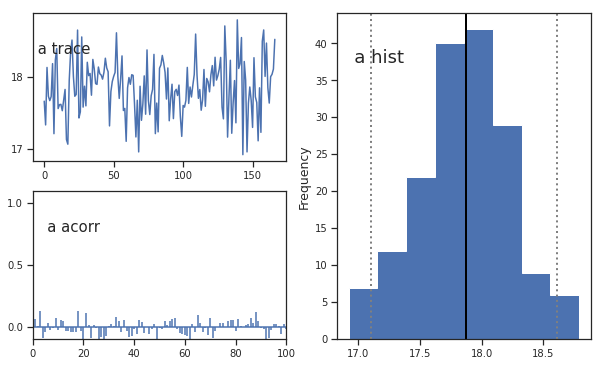

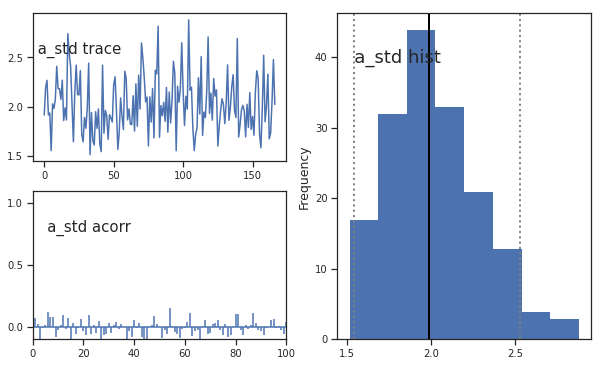

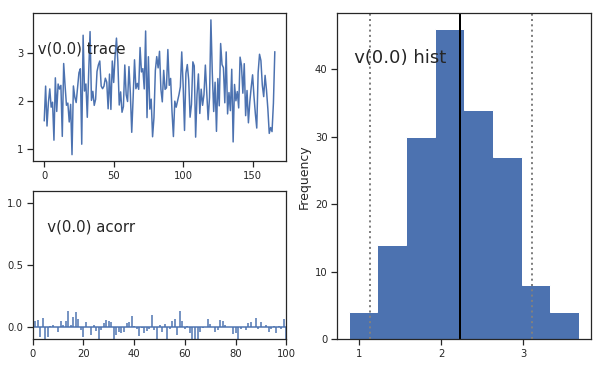

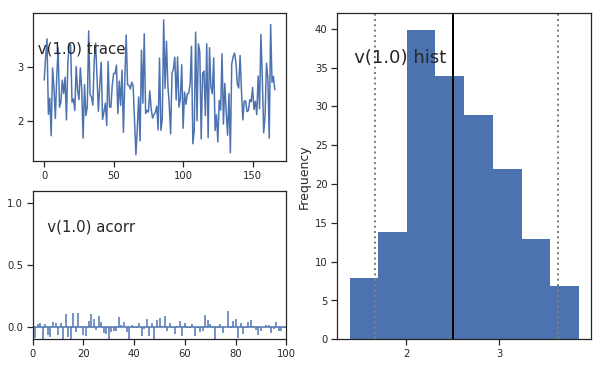

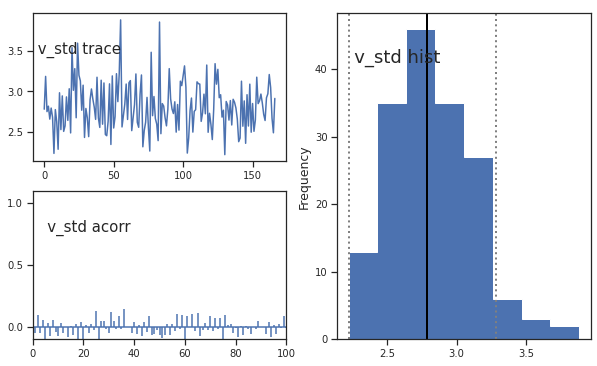

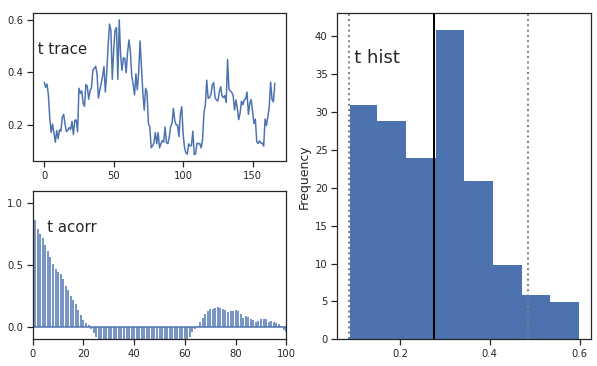

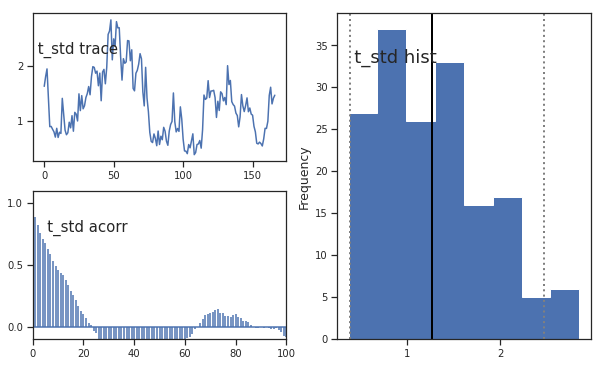

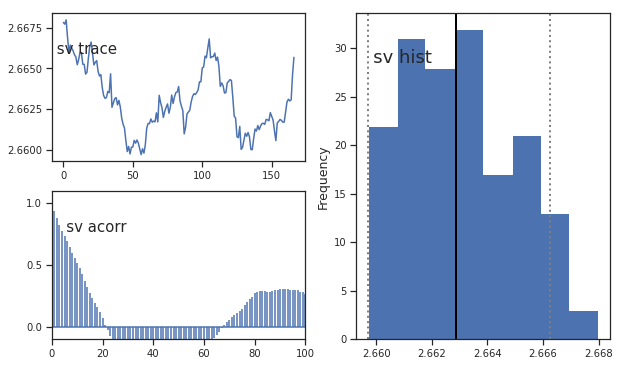

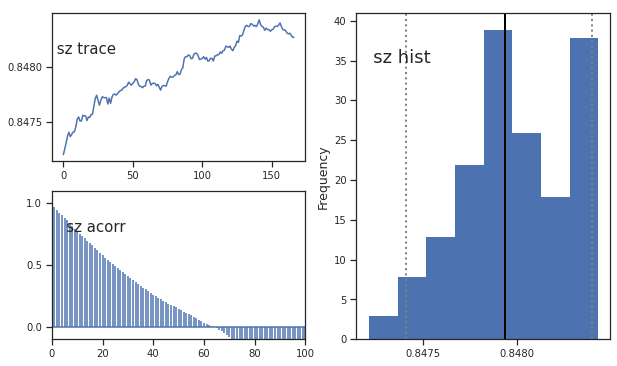

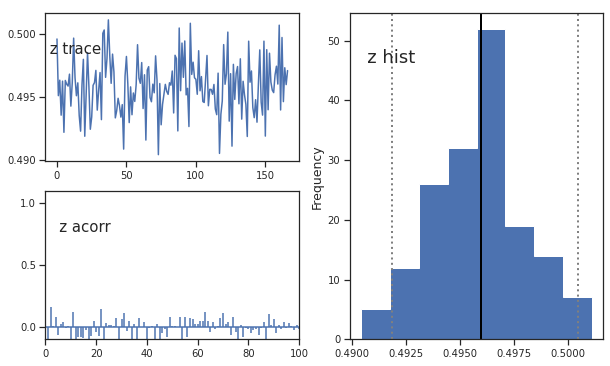

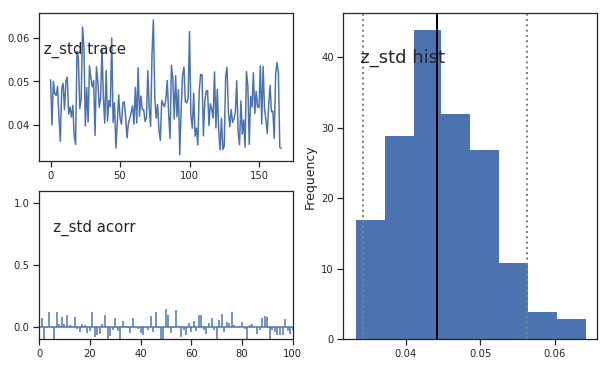

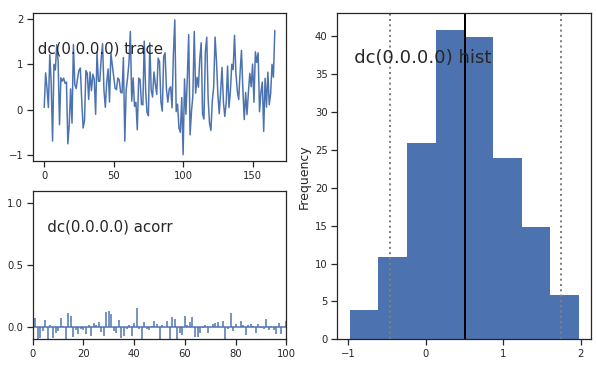

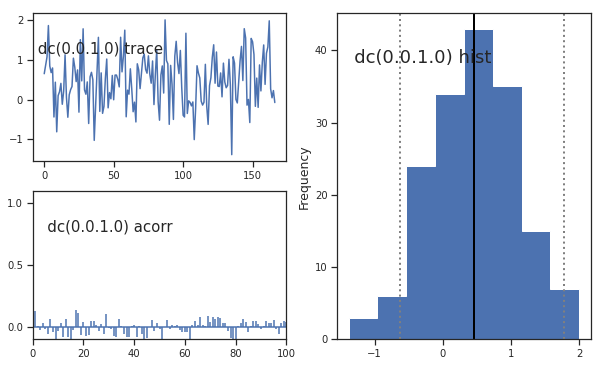

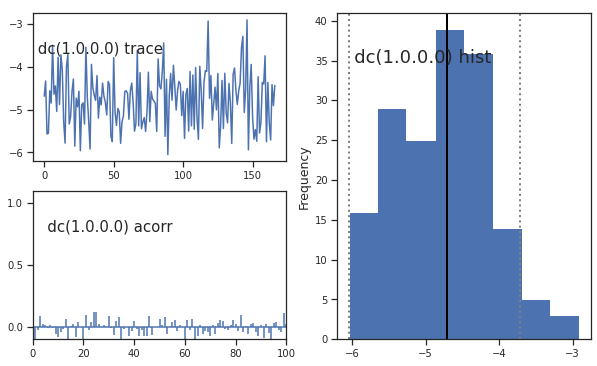

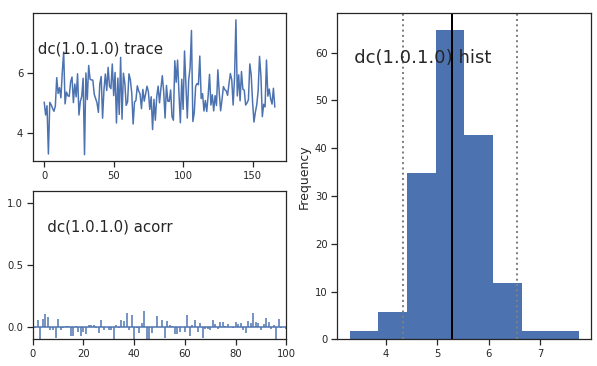

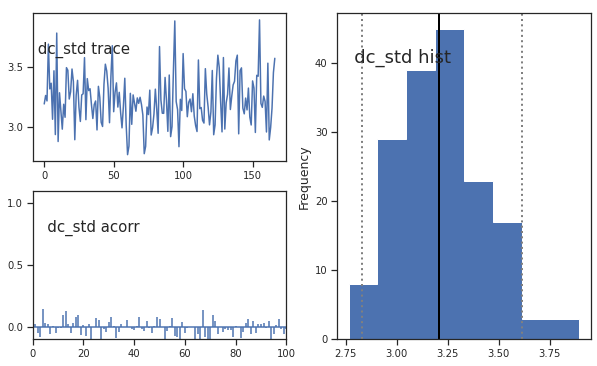

In [458]:
m_Z_stimcoding_dc_prevresp.plot_posteriors()

In [430]:
m_Z_stimcoding_dc_prevresp.save(model_filename+'_fm.db')

In [432]:
m_Z_stimcoding_dc_prevresp.print_stats()

                               mean           std          2.5q           25q           50q           75q         97.5q        mc err
a                      1.785038e+01  3.814625e-01  1.710527e+01  1.762304e+01  1.786934e+01  1.810757e+01  1.861090e+01  3.605651e-02
a_std                  2.026876e+00  2.843315e-01  1.551985e+00  1.815855e+00  1.987773e+00  2.194590e+00  2.693874e+00  2.876463e-02
a_subj.0               1.679569e+01  2.814744e-01  1.628610e+01  1.652679e+01  1.692294e+01  1.703763e+01  1.714527e+01  1.127768e-02
a_subj.1               1.814002e+01  1.406433e-01  1.792786e+01  1.803412e+01  1.811202e+01  1.822904e+01  1.845384e+01  1.008002e-02
a_subj.2               1.712861e+01  1.575452e-01  1.668705e+01  1.707745e+01  1.714590e+01  1.722526e+01  1.736328e+01  1.712153e-02
a_subj.3               1.910415e+01  1.520893e-02  1.908143e+01  1.909254e+01  1.910253e+01  1.911444e+01  1.913563e+01  1.548549e-03
a_subj.4               1.701883e+01  2.565784e-01  1.636661e+0

In [433]:
model_name = simdata + '_sim_Z'

In [434]:
hddm_m_path = os.path.join(results_path,'Group_level_analyses','hddm_models')
model_filename  = os.path.join(hddm_m_path, model_name)


In [435]:
m_Z_stimcoding_z_prevresp = hddm.HDDMStimCoding(mydata, stim_col='Stimuli', split_param='v',
                            drift_criterion=False, bias=True, p_outlier=0.05,
                            include=('sv', 'sz'), group_only_nodes=['sv', 'sz'],
                            depends_on={ 'v':['nrep'], 'z':['nrep','response1']})
m_Z_stimcoding_z_prevresp.sample(n_samples, burn=n_samples/2, thin=3, db='pickle',
        dbname = model_filename + '.db')
                

 [-----------------100%-----------------] 1001 of 1000 complete in 11510.7 sec

In [436]:
m_Z_stimcoding_z_prevresp.save(model_filename+'_fm.db')

Plotting a
Plotting a_std
Plotting v(0.0)
Plotting v(1.0)
Plotting v_std
Plotting t
Plotting t_std
Plotting sv
Plotting sz
Plotting z(0.0.0.0)
Plotting z(0.0.1.0)
Plotting z(1.0.0.0)
Plotting z(1.0.1.0)
Plotting z_std


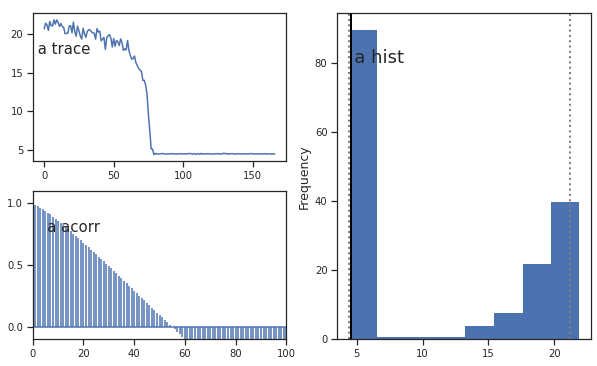

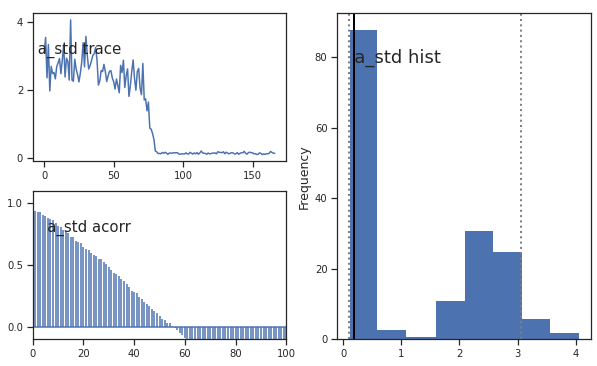

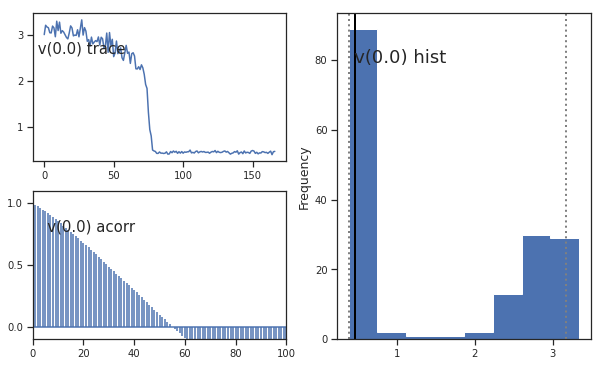

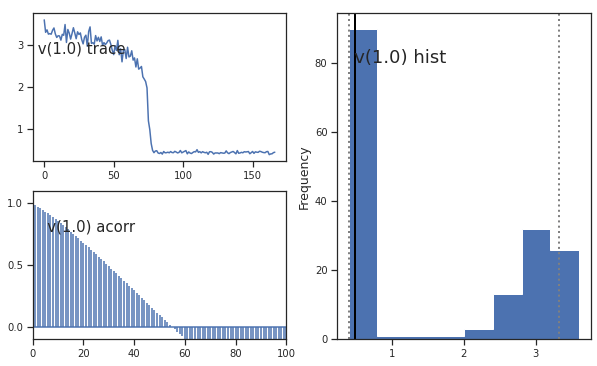

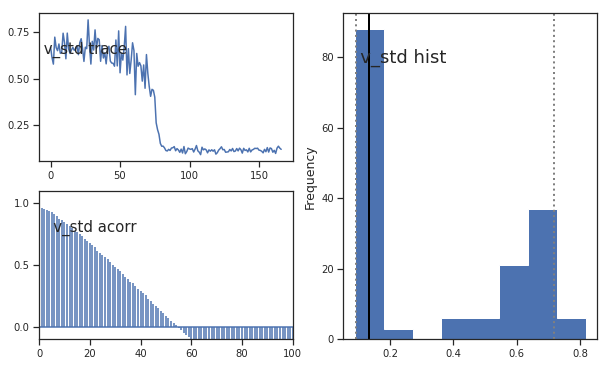

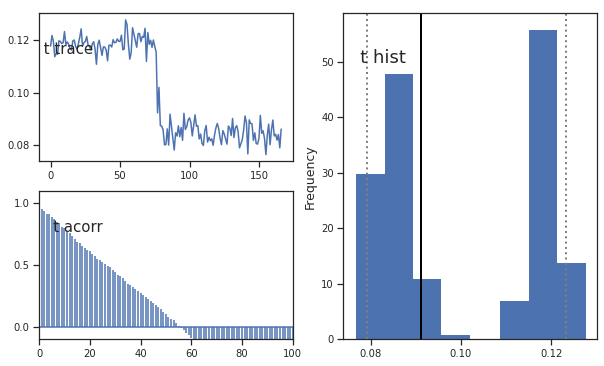

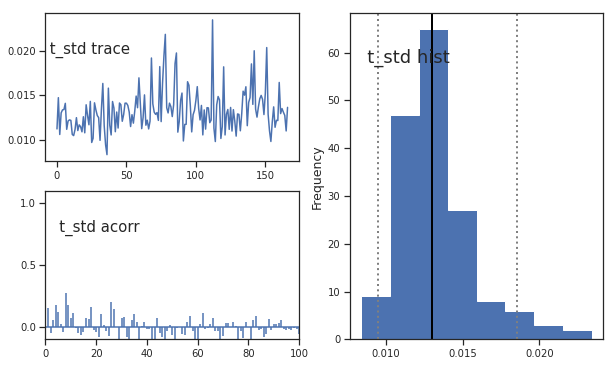

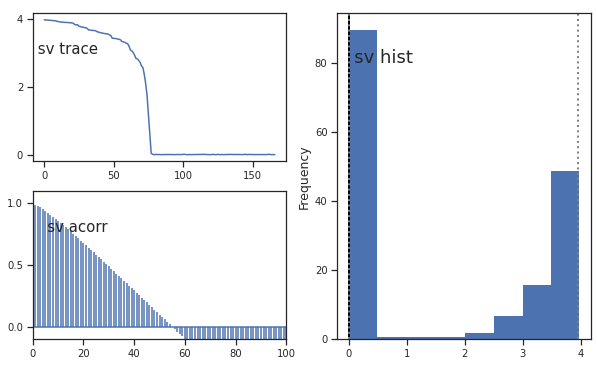

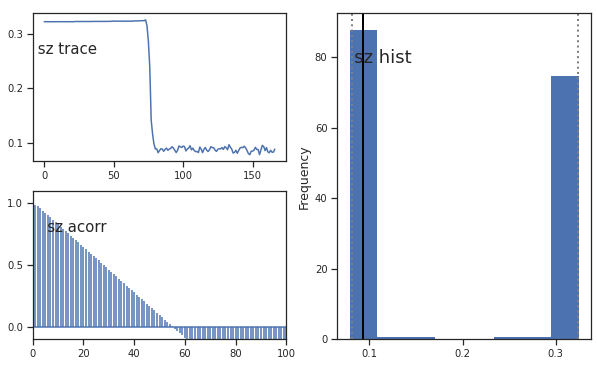

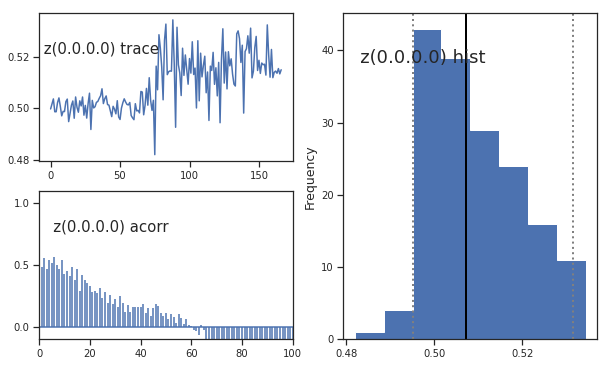

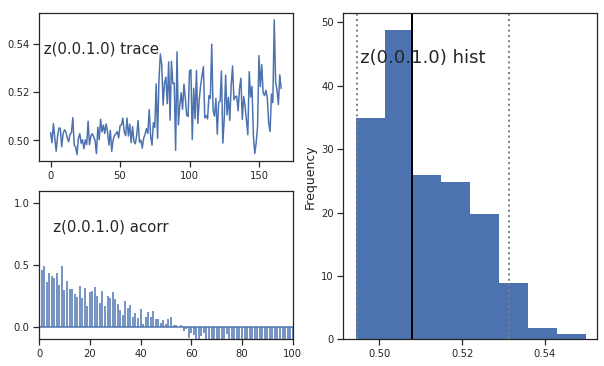

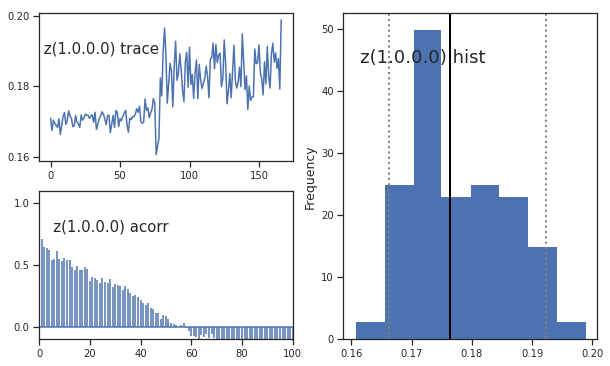

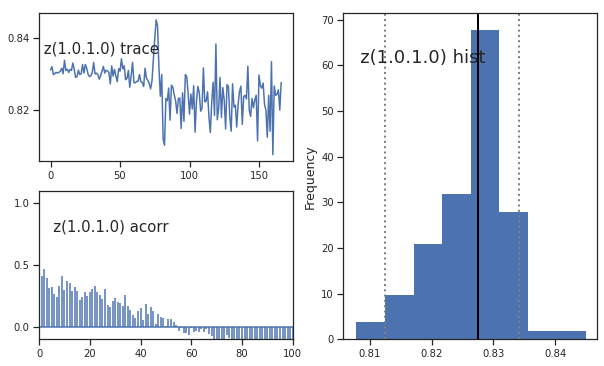

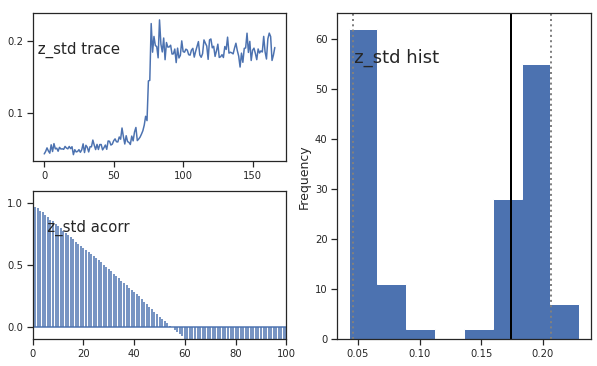

In [437]:
m_Z_stimcoding_z_prevresp.plot_posteriors()

In [438]:
m_Z_stimcoding_z_prevresp.print_stats()

                           mean       std      2.5q       25q       50q        75q      97.5q    mc err
a                     11.184477  7.448550  4.447680  4.488012  4.546669  19.611805  21.566972  0.652421
a_std                  1.249036  1.233582  0.103899  0.135087  0.188101   2.509274   3.334550  0.107444
a_subj.0              12.278085  8.650804  4.458073  4.502592  4.579549  22.069560  24.024588  0.757999
a_subj.1              12.219825  8.424362  4.521415  4.585866  4.643641  21.798987  23.400848  0.730376
a_subj.2              11.247026  7.569102  4.437759  4.509853  4.570725  19.703313  21.832415  0.670468
a_subj.3              12.620369  8.870855  4.530178  4.617936  4.712627  22.701557  24.440718  0.772546
a_subj.4              11.947789  8.181730  4.508190  4.574006  4.653841  21.267171  22.869091  0.714311
a_subj.5              11.895647  8.230561  4.441943  4.512188  4.577760  20.867279  23.489132  0.722073
a_subj.6               9.871984  6.251342  4.259217  4.319303  4

OTHER MODELS

# slope model

In [462]:
simdata = 'slope'

In [463]:
mydata = simdata_slope_bias.copy()
mydata = mydata[mydata.RT > 0.0]
mydata.loc[mydata.stim == -1, 'stim'] = 0
mydata.rename(columns= {'deci' : 'response', 'RT' : 'rt', 'stim':'Stimuli','pre_deci':'response1','nit':'subj_idx'}, inplace=True)
mydata.rt = mydata.rt/100
mydata = mydata[mydata.subj_idx < 25]




<AxesSubplot:title={'center':'RT distributions'}, xlabel='RT', ylabel='count'>

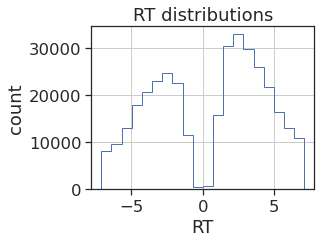

In [464]:
data = hddm.utils.flip_errors(mydata) 
#data = mydata.copy()
fig = plt.figure(figsize=[4,3])
ax = fig.add_subplot(111, xlabel='RT', ylabel='count', title='RT distributions')

data.rt.hist(bins=20, histtype='step', ax=ax)

nohist

In [465]:
model_name = simdata + '_sim_nohist'

In [466]:
hddm_m_path = os.path.join(results_path,'Group_level_analyses','hddm_models')
model_filename  = os.path.join(hddm_m_path, model_name)


In [467]:
m_slope_nohist = hddm.HDDMStimCoding(mydata, stim_col='Stimuli', split_param='v',
                        drift_criterion=False, bias=True, p_outlier=0.05,
                        include=('sv', 'sz'), group_only_nodes=['sv', 'sz'],
                        depends_on={ 'v':['nrep']}) 
m_slope_nohist.sample(n_samples, burn=n_samples/2, thin=3)


 [-----------------100%-----------------] 1001 of 1000 complete in 48235.2 sec

In [468]:
m_slope_nohist.save(model_filename+'_fm.db')

ValueError: db is 'ram'. Saving a model requires a database on disk.

In [ ]:
m_slope_nohist.print_stats()

dc

In [ ]:
model_name = simdata + '_sim_dc'

In [ ]:
hddm_m_path = os.path.join(results_path,'Group_level_analyses','hddm_models')
model_filename  = os.path.join(hddm_m_path, model_name)


In [ ]:
m_slope_stimcoding_dc_prevresp = hddm.HDDMStimCoding(mydata, stim_col='Stimuli', split_param='v',
                            drift_criterion=True, bias=True, p_outlier=0.05,
                            include=('sv', 'sz'), group_only_nodes=['sv', 'sz'],
                            depends_on={ 'dc':['nrep','response1'], 'v':['nrep']})
m_slope_stimcoding_dc_prevresp.sample(n_samples, burn=n_samples/2, thin=3, db='pickle',
        dbname = model_filename + '.db')
                

In [ ]:
m_slope_stimcoding_dc_prevresp.save(model_filename+'_fm.db')

In [ ]:
m_slope_stimcoding_dc_prevresp.print_stats()

z

In [ ]:
model_name = simdata + '_sim_Z'

In [ ]:
hddm_m_path = os.path.join(results_path,'Group_level_analyses','hddm_models')
model_filename  = os.path.join(hddm_m_path, model_name)


In [ ]:
m_slope_stimcoding_z_prevresp = hddm.HDDMStimCoding(mydata, stim_col='Stimuli', split_param='v',
                            drift_criterion=False, bias=True, p_outlier=0.05,
                            include=('sv', 'sz'), group_only_nodes=['sv', 'sz'],
                            depends_on={ 'v':['nrep'], 'z':['nrep','response1']})
m_slope_stimcoding_z_prevresp.sample(n_samples, burn=n_samples/2, thin=3, db='pickle',
        dbname = model_filename + '.db')
                

In [ ]:
m_slope_stimcoding_z_prevresp.save(model_filename+'_fm.db')

In [ ]:
m_slope_stimcoding_z_prevresp.print_stats()

# threshold model

In [439]:
simdata = 'threshold'

In [440]:
mydata = simdata_threshold_bias.copy()
mydata = mydata[mydata.RT > 0.0]
mydata.loc[mydata.stim == -1, 'stim'] = 0
mydata.rename(columns= {'deci' : 'response', 'RT' : 'rt', 'stim':'Stimuli','pre_deci':'response1','nit':'subj_idx'}, inplace=True)
mydata.rt = mydata.rt/100
mydata = mydata[mydata.subj_idx < 25]


<AxesSubplot:title={'center':'RT distributions'}, xlabel='RT', ylabel='count'>

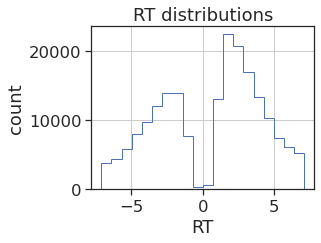

In [441]:
data = hddm.utils.flip_errors(mydata) 
#data = mydata.copy()
fig = plt.figure(figsize=[4,3])
ax = fig.add_subplot(111, xlabel='RT', ylabel='count', title='RT distributions')

data.rt.hist(bins=20, histtype='step', ax=ax)

nohist

In [442]:
model_name = simdata + '_sim_nohist'

In [443]:
hddm_m_path = os.path.join(results_path,'Group_level_analyses','hddm_models')
model_filename  = os.path.join(hddm_m_path, model_name)


In [ ]:
m_threshold_nohist = hddm.HDDMStimCoding(mydata, stim_col='Stimuli', split_param='v',
                        drift_criterion=False, bias=True, p_outlier=0.05,
                        include=('sv', 'sz'), group_only_nodes=['sv', 'sz'],
                        depends_on={ 'v':['nrep']}) 
m_threshold_nohist.sample(n_samples, burn=n_samples/2, thin=3, db='pickle',
        dbname = model_filename + '.db')


 [-----------------59%--                ] 598 of 1000 complete in 10278.1 sec

In [ ]:
m_threshold_nohist.save(model_filename+'_fm.db')

In [459]:
m_threshold_nohist.print_stats()

                       mean       std       2.5q        25q        50q        75q      97.5q    mc err
a                  7.203724  1.913253   4.593083   5.980029   7.010889   8.146576  12.657032  0.207329
a_std             11.274041  1.005228   9.212598  10.622896  11.169610  11.939948  13.486461  0.102438
a_subj.0          69.586645  0.634897  69.099986  69.137386  69.196368  70.150717  70.865687  0.004306
a_subj.1          73.633004  0.632203  72.514921  73.063096  73.615192  74.362949  74.561831  0.072743
a_subj.2          14.343359  0.235140  13.926963  14.183568  14.325649  14.523310  14.779465  0.023044
a_subj.3          64.940587  0.211778  64.546226  64.795003  64.932180  65.125709  65.279408  0.017868
a_subj.4          13.149923  0.262146  12.676757  12.965034  13.128269  13.345750  13.672952  0.022939
a_subj.5          70.921897  0.692966  69.823881  70.205035  71.153757  71.519850  72.009613  0.036505
a_subj.6          64.125221  0.169041  63.794873  63.968899  64.175129  6

In [ ]:
model_name = simdata + '_sim_dc'

In [ ]:
hddm_m_path = os.path.join(results_path,'Group_level_analyses','hddm_models')
model_filename  = os.path.join(hddm_m_path, model_name)


In [ ]:
m_threshold_stimcoding_dc_prevresp = hddm.HDDMStimCoding(mydata, stim_col='Stimuli', split_param='v',
                            drift_criterion=True, bias=True, p_outlier=0.05,
                            include=('sv', 'sz'), group_only_nodes=['sv', 'sz'],
                            depends_on={ 'dc':['nrep','response1'], 'v':['nrep']})
m_threshold_stimcoding_dc_prevresp.sample(n_samples, burn=n_samples/2, thin=3, db='pickle',
        dbname = model_filename + '.db')
                

In [ ]:
m_threshold_stimcoding_dc_prevresp.save(model_filename+'_fm.db')

In [460]:
m_threshold_stimcoding_dc_prevresp.print_stats()

                            mean       std       2.5q        25q        50q        75q      97.5q    mc err
a                       7.109397  1.807071   4.222611   5.769416   6.893170   8.141069  11.565272  0.177281
a_std                  12.115409  1.138911  10.197970  11.255116  12.181547  12.889310  14.488136  0.105425
a_subj.0               69.846680  0.422298  68.957346  69.621415  70.020256  70.139408  70.433983  0.020916
a_subj.1               72.415279  0.527538  71.657090  72.050717  72.261758  72.698831  73.555560  0.029719
a_subj.2               31.259925  0.451415  30.104050  31.039013  31.315661  31.583225  32.022257  0.034113
a_subj.3               32.858101  0.561488  31.704487  32.547767  32.939559  33.228007  33.931891  0.048172
a_subj.4               34.233625  0.972822  32.242541  33.597158  34.133353  34.906728  36.217079  0.080213
a_subj.5               67.360409  1.740178  62.471180  67.794005  67.949181  68.098877  68.706396  0.216035
a_subj.6               70.55

In [ ]:
m_threshold_stimcoding_dc_prevresp.print_stats()

In [ ]:
model_name = simdata + '_sim_Z'

In [ ]:
hddm_m_path = os.path.join(results_path,'Group_level_analyses','hddm_models')
model_filename  = os.path.join(hddm_m_path, model_name)


In [ ]:
m_threshold_stimcoding_z_prevresp = hddm.HDDMStimCoding(mydata, stim_col='Stimuli', split_param='v',
                            drift_criterion=False, bias=True, p_outlier=0.05,
                            include=('sv', 'sz'), group_only_nodes=['sv', 'sz'],
                            depends_on={ 'v':['nrep'], 'z':['nrep','response1']})
m_threshold_stimcoding_z_prevresp.sample(n_samples, burn=n_samples/2, thin=3, db='pickle',
        dbname = model_filename + '.db')
                

In [ ]:
m_threshold_stimcoding_z_prevresp.save(model_filename+'_fm.db')

In [461]:
m_threshold_stimcoding_z_prevresp.print_stats()

                           mean       std       2.5q        25q        50q        75q      97.5q    mc err
a                      8.658280  1.969434   5.328074   7.158713   8.502391  10.171021  13.047381  0.194187
a_std                 10.375302  0.894856   8.443889   9.804813  10.444044  10.976588  12.031510  0.096096
a_subj.0              59.952254  0.578721  58.665868  59.549920  60.122001  60.284943  61.176204  0.051452
a_subj.1              65.550610  0.235331  65.155633  65.413937  65.471036  65.737283  66.079806  0.028152
a_subj.2              11.994349  0.563082  11.313464  11.528497  11.828102  12.374199  13.228175  0.053185
a_subj.3              57.711876  1.420234  55.872708  56.436944  57.277910  59.136139  59.917763  0.085971
a_subj.4              10.800109  0.544949  10.125110  10.389050  10.609883  10.977141  11.935379  0.053483
a_subj.5              73.885496  0.787455  73.083077  73.262647  73.381345  74.867409  75.223229  0.071244
a_subj.6              52.467483  0.09